# 23 — Where RNA sits in and around cells in EAE lesions

Cell-by-gene tables throw away *where* in the cell each transcript was. With the stain-based outlines and the nuclei
we can ask what cells are doing with their RNA in lesions. Four questions, all runs 5/6 (25 animals, transcripts are
only available there):

1. **Do oligodendrocytes in lesions still send myelin RNA out to their sheaths?** *Mbp* mRNA is transported out of
   the cell body into the processes and translated where myelin is made; its sister myelin genes (*Mag*, *Mog*,
   *Cldn11*, …) stay near the soma and serve as the control.
2. **What do macrophages and microglia carry inside them?** Myelin and axon transcripts deep inside a myeloid cell's
   outline, relative to how much is around it, as a trace of engulfed material. Spillover from neighbours is the
   alternative, so non-phagocytic cells in the same place are the baseline.
3. **Do lesion cells hold their RNA back in the nucleus?** Nuclear retention of mRNA is a stress response.
4. **What does the space between cells lose in white-matter lesions: myelin RNA or neuron-derived RNA?** The RNA counterpart
   of the ~17 % ATP1A1 neuropil loss (notebooks 20, 22).

**Design.** Input: `scripts/04_transcript_compartments.py` (every transcript with qv >= 20: in a cell or not, in the
nucleus or not, depth inside the cell, nearest cell and distance outside). Lesion zones from the lesion regions
(notebook 16, signed distance to the region edge): **core** >= 30 µm inside, **edge** ±30 µm, **near** 30–150 µm
outside, **healthy** > 150 µm outside or no region, and not called lesion. Counts are pooled per animal and zone (the
animal is the unit); core vs healthy is a paired test across animals (Wilcoxon). Cross-sectional: these are
associations.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import scipy.sparse as sp
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, wilcoxon
from skimage.segmentation import find_boundaries
from statsmodels.stats.multitest import multipletests

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/23_rna_in_and_around_cells.ipynb"
OUT = ROOT / "results" / "23_rna_in_and_around_cells"
OUT.mkdir(parents=True, exist_ok=True)
SUB = ROOT / "data" / "subcellular"
COL = plotting.CATEGORICAL
WM = ["WM", "WM_Meningeal"]
HALO = 10.0
ZONES = ["healthy", "near", "edge", "core"]
ZCOL = dict(zip(ZONES, ["#4c9a6a", "#9cc28a", "#e0a040", "#c0392b"]))
STAGES = ["CFA", "NONSYMPTOM", "OS1", "PEAK1", "REMISSION1", "PEAK2", "REMISSION2", "PEAK3", "MILD16", "SEVERE16",
          "SEVERE30"]
SETS = {
    "mbp": ["Mbp"],
    "myelin_ctrl": ["Mag", "Mog", "Cldn11", "Mal", "Opalin", "Enpp6"],
    "cnp": ["Cnp"],
    "oligo_soma": ["Sox10", "Olig1", "Olig2", "Nkx6-2", "Myrf", "St18"],
    "axon": ["Nefl", "Nefm", "Nefh", "Stmn2", "Gap43"],
    "neuron_soma": ["Snap25", "Camk2a", "Rbfox3", "Syt1"],
    "cd68": ["Cd68"],
    "phago": ["Trem2", "Lpl", "Cd36", "Gpnmb", "Axl"],
    "astro": ["Gfap", "Aqp4", "Slc1a2", "Slc1a3"],
    "stress": ["Neat1", "Hspa1a", "Hspa1b", "Ddit3", "Fos", "Jun", "Atf4", "Hsph1"],
}
MYELIN = ["mbp", "myelin_ctrl", "cnp"]

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[a.obs.run_id.isin(["run5", "run6"])][
    ["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated", "Curated_niche_state",
     "Global_anatomical_region", "x_centroid", "y_centroid", "cell_area", "nucleus_area", "segmentation_method",
     "run_id"]].copy()
genes = a.var_names.copy()
del a
for c in ["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated", "Curated_niche_state",
          "Global_anatomical_region", "segmentation_method", "run_id"]:
    obs[c] = obs[c].astype(str)
obs["arm"] = np.where(obs.model.str.startswith("CHRONIC"), "chronic", "RR")
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state", "ctype"]])
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion16" / "regions.parquet")[["reg", "reg_dist"]])
rd = obs.reg_dist
obs["zone"] = np.select(
    [rd >= 30, rd >= -30, rd >= -150, ((rd < -150) | rd.isna()) & (obs.lesion_state == "no lesion")],
    ["core", "edge", "near", "healthy"], default="other")
obs["wm"] = obs.Global_anatomical_region.isin(WM)
# second lesion definition for the robustness checks: curated lesion niches vs physiological niche
obs["zone_cur"] = np.select([obs.Curated_niche_state.str.startswith("Lesion"), obs.Curated_niche_state == "Physiological"],
                            ["core", "healthy"], default="other")
obs["seg"] = obs.segmentation_method.str.replace("Segmented by ", "", regex=False)
ARM = obs.drop_duplicates("sample_name").set_index("sample_name").arm
clin = pd.read_csv(ROOT / "data" / "clinical" / "animal_course_metrics.csv", index_col=0)
print(obs.zone.value_counts().to_string())
print(pd.crosstab(obs.drop_duplicates("sample_name").stage, obs.drop_duplicates("sample_name").arm).to_string())

zone
core       158155
edge       102236
healthy     96688
near        91113
other       52187
arm         RR  chronic
stage                  
CFA          0        2
MILD16       0        3
NONSYMPTOM   0        2
OS1          0        1
PEAK1        1        3
PEAK2        1        0
PEAK3        2        0
REMISSION1   2        0
REMISSION2   3        0
SEVERE16     0        3
SEVERE30     0        2


**Per-cell compartment counts.** For every annotated cell: transcripts in the cell and in its nucleus (all genes and
the gene sets above); transcripts *outside* any cell whose nearest cell is this one, within 10 µm (its "halo"), with
the free area that halo covers; and, for the gene sets, how many transcripts sit at the rim of the outline (< 1 µm
from it) or deep inside (>= 2 µm). For the gene-level nuclear screen (question 3), counts are pooled per animal ×
cell type × zone.

In [3]:
gi = pd.Series(np.arange(len(genes)), index=genes)
sidx = {k: gi.reindex(v).dropna().astype(int).to_numpy() for k, v in SETS.items()}
gene2set = {g: k for k, v in SETS.items() for g in v}
print({k: len(v) for k, v in sidx.items()})

parts, pool_keys, pool_tot, pool_nuc = [], [], [], []
for sid in sorted(obs.sample_id.unique()):
    z = np.load(SUB / f"{sid}.npz", allow_pickle=True)
    names = z["obs_names"]
    n, G = len(names), len(genes)
    tot = sp.csr_matrix((z["total_data"], z["total_indices"], z["total_indptr"]), shape=(n, G))
    nuc = sp.csr_matrix((z["nuclear_data"], z["nuclear_indices"], z["nuclear_indptr"]), shape=(n, G))
    d = pd.DataFrame(index=pd.Index(names, name="obs_id"))
    d["n_total"], d["n_nuc"] = tot.sum(1).A1, nuc.sum(1).A1
    for k, ix in sidx.items():
        d[f"{k}_cell"], d[f"{k}_nuc"] = tot[:, ix].sum(1).A1, nuc[:, ix].sum(1).A1
    d["halo_area"], d["halo_all"] = z["halo_area_um2"], z["halo_all"]
    p = pd.read_parquet(SUB / f"{sid}_points.parquet", columns=["gene", "in_cell", "cell", "depth_um", "near_cell",
                                                                  "dist_um"])
    p["set"] = p.gene.astype(str).map(gene2set)
    h = p[~p.in_cell & (p.dist_um <= HALO) & p.near_cell.notna()]
    d = d.join(h.groupby(["near_cell", "set"]).size().unstack(fill_value=0).add_prefix("halo_"))
    c = p[p.in_cell & p.cell.notna()]
    lay = np.where(c.depth_um < 1, "rim", np.where(c.depth_um >= 2, "deep", "mid"))
    dd = c.groupby([c.cell, c.set, lay]).size().unstack([1, 2], fill_value=0)
    dd.columns = [f"{l}_{s}" for s, l in dd.columns]
    parts.append(d.join(dd))
    # pooled counts per animal x cell type x zone (healthy / core), for the gene-level nuclear screen
    o = obs.loc[names]
    keep = o.zone.isin(["healthy", "core"]).to_numpy()
    key = (o.sample_name + "|" + o.ctype.astype(str) + "|" + o.zone).to_numpy()
    codes, uniq = pd.factorize(key[keep])
    ind = sp.csr_matrix((np.ones(len(codes)), (codes, np.flatnonzero(keep))), shape=(len(uniq), n))
    pool_keys += list(uniq)
    pool_tot.append((ind @ tot).toarray().astype(np.float32))
    pool_nuc.append((ind @ nuc).toarray().astype(np.float32))
cells = obs.join(pd.concat(parts).fillna(0), how="inner")
# distance from each WM cell to the nearest grey-matter cell of the same piece (anatomy control, section 4)
GMR = ["GM", "DorsalHorn", "VentralHorn"]
cells["d_gm"] = np.nan
for pc_, g in cells.groupby("meta_sample_id"):
    gm, wmc = g[g.Global_anatomical_region.isin(GMR)], g[g.wm]
    if len(gm) >= 20 and len(wmc):
        cells.loc[wmc.index, "d_gm"] = cKDTree(gm[["x_centroid", "y_centroid"]].to_numpy()).query(
            wmc[["x_centroid", "y_centroid"]].to_numpy())[0]
cells["size_third"] = cells.groupby("Anno_L1_curated").cell_area.transform(
    lambda x: pd.qcut(x.rank(method="first"), 3, labels=["small", "mid", "large"])).astype(str)
cells.drop(columns=[c for c in cells if cells[c].dtype == object and c not in obs]).to_parquet(
    SUB / "cells_compartments.parquet")
# an animal can have pieces on several sections: sum its pools across sections
codes, uniq = pd.factorize(np.array(pool_keys))
agg = sp.csr_matrix((np.ones(len(codes)), (codes, np.arange(len(codes)))), shape=(len(uniq), len(codes)))
pool = pd.DataFrame({"key": uniq})
pool_tot, pool_nuc = agg @ np.vstack(pool_tot), agg @ np.vstack(pool_nuc)
print(f"{len(cells):,} cells; {cells.n_total.sum():,.0f} transcripts in cells; "
      f"{cells.halo_all.sum():,.0f} outside cells within {HALO:.0f} µm of one")

{'mbp': 1, 'myelin_ctrl': 6, 'cnp': 1, 'oligo_soma': 5, 'axon': 5, 'neuron_soma': 3, 'cd68': 1, 'phago': 5, 'astro': 3, 'stress': 8}


500,379 cells; 584,970,965 transcripts in cells; 373,750,367 outside cells within 10 µm of one


Helpers: a value per animal × zone from pooled counts (needs >= 20 cells), the core-vs-healthy contrast across
animals, and a zone profile (each animal's value ÷ its own healthy value).

In [4]:
def per_zone(d, fn, by=("sample_name", "zone"), min_cells=20):
    g = d.groupby(list(by), observed=True)
    v = g.apply(fn)
    return v[g.size() >= min_cells]


def ratio(num, den):
    return lambda g: g[num].sum() / g[den].sum() if g[den].sum() > 0 else np.nan


def contrast(v, a="healthy", b="core"):
    w = v.unstack()
    if a not in w or b not in w:
        return dict(animals=0)
    lf = np.log2(w[b] / w[a]).replace([np.inf, -np.inf], np.nan).dropna()
    return dict(animals=len(lf), core_over_healthy=2 ** lf.median(), share_lower=(lf < 0).mean(),
                p=wilcoxon(lf).pvalue if len(lf) >= 5 else np.nan)


def profile(ax, v, label, color, ref="healthy"):
    w = v.unstack().reindex(columns=ZONES)
    w = w.div(w[ref], axis=0).replace([np.inf, -np.inf], np.nan)
    m, q1, q3 = w.median(), w.quantile(0.25), w.quantile(0.75)
    x = np.arange(len(ZONES))
    ax.plot(x, m, marker="o", color=color, label=f"{label} (n={w[ZONES[-1]].notna().sum()})")
    ax.fill_between(x, q1, q3, color=color, alpha=0.15)
    ax.set_xticks(x, ZONES)
    ax.axhline(1, color="0.6", lw=0.8, ls="--")


def report(rows):
    t = pd.DataFrame(rows)
    return t.round(3)


def robust(d, vfn, label):
    """The same core-vs-healthy contrast under each confound check. vfn(cells, by) -> value per (animal, zone)."""
    z = ("sample_name", "zone")
    checks = [("main: lesion-region zones", d, z), ("curated lesion niches vs physiological", d, ("sample_name", "zone_cur"))]
    checks += [(f"{r} only", d[d.run_id == r], z) for r in ["run5", "run6"]]
    checks += [(f"segmented by {m}", s, z) for m, s in d.groupby("seg") if len(s) > 2000]
    checks += [(f"{k} cells (size third)", s, z) for k, s in d.groupby("size_third")]
    if d.d_gm.notna().mean() > 0.5:  # white-matter analyses: same distance band from grey matter
        checks += [("WM 0–100 µm from grey matter", d[d.d_gm <= 100], z),
                   ("WM 100–400 µm from grey matter", d[d.d_gm.between(100, 400)], z)]
    rows = []
    for name, s, by in checks:
        try:
            rows.append(dict(readout=label, check=name, **contrast(vfn(s, by))))
        except (KeyError, ValueError, ZeroDivisionError):
            rows.append(dict(readout=label, check=name, animals=0))
    return pd.DataFrame(rows)


def paired_plot(ax, v, title, a="healthy", b="core", log=True):
    w = v.unstack()
    if a not in w or b not in w:
        return
    w = w[[a, b]].replace([np.inf, -np.inf], np.nan).dropna()
    for an_, r in w.iterrows():
        ax.plot([0, 1], [r[a], r[b]], color=COL[0] if ARM.get(an_) == "chronic" else COL[1], alpha=0.6, marker="o", ms=3,
                lw=1)
    if log:
        ax.set_yscale("log")
    ax.set_xticks([0, 1], [a, b])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f"{title}\n{(w[b] < w[a]).sum()} of {len(w)} animals lower in {b}", fontsize=8)


def zf(fn):
    """per-zone value function for robust(): fn applied to pooled cells."""
    return lambda s, by: per_zone(s, fn, by=by)


def fmt(t):
    """one cell per check x readout: '×ratio (k/n animals lower, p)'."""
    t = t.copy()
    order = list(dict.fromkeys(t.check))
    def cell(r):
        if not r.get("animals") or pd.isna(r.get("core_over_healthy")):
            return "n/a"
        k = int(round(r.share_lower * r.animals))
        return f"×{r.core_over_healthy:.2f} ({k}/{int(r.animals)} lower, p={r.p:.2g})"
    t["result"] = t.apply(cell, axis=1)
    return t.pivot(index="check", columns="readout", values="result").reindex(order)

In [5]:
# image helpers: crops with outlines, nuclei and transcripts; random galleries
cfg = data.load_config()
cfg["runs"] = {k: v for k, v in cfg["runs"].items() if k in ("run5", "run6")}
bundles = find_bundles(cfg)


def crop_points(sid, x0, y0, w):
    t = pq.read_table(SUB / f"{sid}_points.parquet", columns=["x", "y", "gene", "in_cell"],
                      filters=[("x", ">=", x0), ("x", "<", x0 + w), ("y", ">=", y0), ("y", "<", y0 + w)])
    return t.to_pandas()


_LAB, _BUN = {}, {}


def cell_labels(sid):
    """cell_id -> mask label (cells.parquet row + 1; order checked against cells.zarr in io.XeniumBundle.cells)."""
    if sid not in _LAB:
        c = pd.read_parquet(bundles[sid] / "cells.parquet", columns=["cell_id"]).cell_id
        _LAB[sid] = pd.Series(np.arange(1, len(c) + 1), index=c.to_numpy())
    return _LAB[sid]


def show_crop(ax, row, w_um, layers, cell_hl=None, hl_color="#f1c40f", title=""):
    if row.sample_id not in _BUN:
        _BUN[row.sample_id] = XeniumBundle(bundles[row.sample_id])
    b = _BUN[row.sample_id]
    px = b.pixel_size
    x0, y0 = row.x_centroid - w_um / 2, row.y_centroid - w_um / 2
    img, lab, nucl = b.read_window(int(y0 / px), int(x0 / px), int(w_um / px), int(w_um / px))
    bnd = img[1]
    ax.imshow(np.clip(bnd / np.percentile(bnd, 99.5), 0, 1), cmap="gray", extent=(0, w_um, w_um, 0))
    edges = find_boundaries(lab, mode="inner")
    ov = np.zeros((*lab.shape, 4))
    ov[edges] = (0.55, 0.55, 0.55, 0.5)
    ov[find_boundaries(nucl, mode="inner")] = (0.35, 0.55, 1.0, 0.6)
    if cell_hl is not None:
        ids = cell_labels(row.sample_id)
        hl = ids.reindex(cell_hl).dropna().astype(int).to_numpy()
        ov[edges & np.isin(lab, hl)] = (*plt.matplotlib.colors.to_rgb(hl_color), 1)
    ax.imshow(ov, extent=(0, w_um, w_um, 0))
    p = crop_points(row.sample_id, x0, y0, w_um)
    for genes_, inside, color, sz in layers:
        q = p[p.gene.astype(str).isin(genes_)]
        if inside is not None:
            q = q[q.in_cell == inside]
        ax.scatter(q.x - x0, q.y - y0, s=sz, c=color, lw=0, alpha=0.8)
    ax.set_title(title, fontsize=8)
    ax.axis("off")


def gallery(groups, w_um, layers, n=6, seed=0, suptitle="", name=None):
    """n random cells per group, one per animal (random animals), same layers; rows = groups."""
    rng_ = np.random.default_rng(seed)
    fig, axs = plt.subplots(len(groups), n, figsize=(2.6 * n, 2.8 * len(groups)), squeeze=False)
    for i, (lab_, s) in enumerate(groups):
        an_ = rng_.permutation(s.sample_name.unique())[:n]
        for j, a_ in enumerate(an_):
            sa = s[s.sample_name == a_]
            r = sa.iloc[rng_.integers(len(sa))]
            show_crop(axs[i, j], r, w_um, layers, cell_hl=[r.name.split(":")[1]],
                      title=f"{lab_} · {a_} ({r.stage})")
        for j in range(len(an_), n):
            axs[i, j].axis("off")
    fig.suptitle(suptitle, fontsize=9)
    fig.tight_layout()
    if name:
        plotting.save_fig(fig, name, OUT, SRC)

## 0. Sanity: where each gene's RNA sits in healthy tissue
Before looking at lesions: share of each focus gene's transcripts inside cell outlines, and of those, in the nucleus
(healthy zone, all cells pooled). Expectations from cell biology: *Mbp* mostly outside cell bodies (transported into
myelin), *Mag*/*Mog*/*Sox10* near the soma, neurofilaments outside (axons), *Neat1* nuclear.

In [6]:
hz = cells[cells.zone == "healthy"]
rows = []
for k in SETS:
    inc, out = hz[f"{k}_cell"].sum(), hz.get(f"halo_{k}", pd.Series(0)).sum()
    rows.append(dict(gene_set=k, genes=", ".join(SETS[k]), in_cells=inc / (inc + out),
                     nuclear_of_in_cell=hz[f"{k}_nuc"].sum() / max(inc, 1)))
san = pd.DataFrame(rows).set_index("gene_set")
san["nuclear_of_in_cell (all genes)"] = hz.n_nuc.sum() / hz.n_total.sum()
san.round(2).to_csv(OUT / "sanity_localisation_healthy.csv")
san.round(2)

,genes,in_cells,nuclear_of_in_cell,nuclear_of_in_cell (all genes)
gene_set,,,,
mbp,Mbp,0.22,0.41,0.5
myelin_ctrl,"Mag, Mog, Cldn11, Mal, Opalin, Enpp6",0.75,0.60,0.5
cnp,Cnp,0.64,0.52,0.5
oligo_soma,"Sox10, Olig1, Olig2, Nkx6-2, Myrf, St18",0.64,0.60,0.5
axon,"Nefl, Nefm, Nefh, Stmn2, Gap43",0.38,0.30,0.5
neuron_soma,"Snap25, Camk2a, Rbfox3, Syt1",0.47,0.35,0.5
cd68,Cd68,0.63,0.57,0.5
phago,"Trem2, Lpl, Cd36, Gpnmb, Axl",0.47,0.52,0.5
astro,"Gfap, Aqp4, Slc1a2, Slc1a3",0.32,0.40,0.5


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/sanity_localisation_healthy.png')

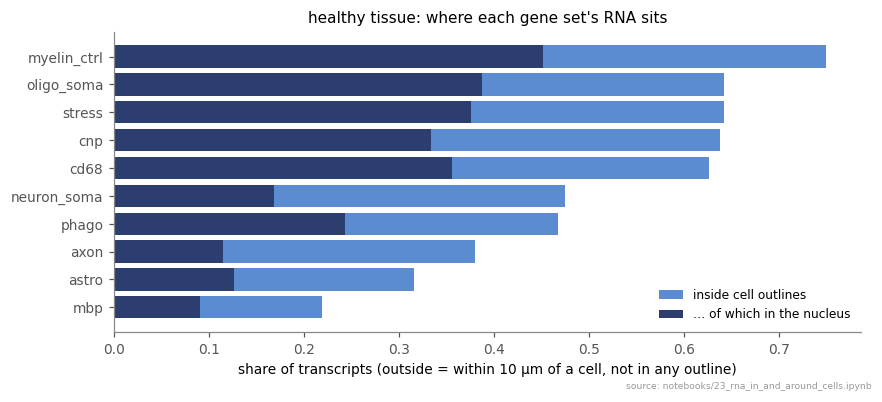

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
s = san.sort_values("in_cells")
ax.barh(s.index, s.in_cells, color="#5b8bd0", label="inside cell outlines")
ax.barh(s.index, s.in_cells * s.nuclear_of_in_cell, color="#2c3e70", label="… of which in the nucleus")
ax.set_xlabel("share of transcripts (outside = within 10 µm of a cell, not in any outline)")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("healthy tissue: where each gene set's RNA sits")
fig.tight_layout()
plotting.save_fig(fig, "sanity_localisation_healthy", OUT, SRC)

## 1. Do oligodendrocytes in lesions still send *Mbp* out?
White-matter oligodendrocytes (`Anno_L1_curated`). Three readouts per animal × zone:
- **Mbp kept in the cell body**: *Mbp* in the outline ÷ control myelin genes in the outline. Rises if *Mbp* piles up
  in the soma (transport failure), falls if the cell sends it all out or stops making it relative to the others.
- ***Mbp* in the nucleus**: nuclear share of *Mbp* ÷ nuclear share of the control genes.
- **Own *Mbp* halo**: *Mbp* density (per µm² of free space) within 10 µm of oligodendrocytes ÷ the same around other
  white-matter cells of the zone (the ambient myelin RNA). Above 1 = the oligodendrocyte has its own exported *Mbp*
  around it; this corrects for myelin simply being lost from the lesion.

Oligodendrocyte state matters (disease-associated oligodendrocytes, DAO, express myelin genes differently), so the
readouts are also split by state (`ctype`: MOL, NFOL, DAO).

In [8]:
wm = cells[cells.wm]
ol = wm[wm.Anno_L1_curated == "Oligodendrocyte"]
other = wm[~wm.Anno_L1_curated.isin(["Oligodendrocyte", "OPC"])]
r_soma = per_zone(ol, ratio("mbp_cell", "myelin_ctrl_cell"))
r_nuc = per_zone(ol, lambda g: (g.mbp_nuc.sum() / g.mbp_cell.sum()) / (g.myelin_ctrl_nuc.sum() / g.myelin_ctrl_cell.sum()))
r_halo = per_zone(ol, ratio("halo_mbp", "halo_area")) / per_zone(other, ratio("halo_mbp", "halo_area"))
r_amb = per_zone(other, ratio("halo_mbp", "halo_area"))
r_ctrl = per_zone(ol, ratio("myelin_ctrl_cell", "n_total"))
q1 = report([dict(readout="Mbp ÷ control myelin genes in the soma", **contrast(r_soma)),
             dict(readout="Mbp nuclear share ÷ control nuclear share", **contrast(r_nuc)),
             dict(readout="own Mbp halo ÷ ambient Mbp (other WM cells)", **contrast(r_halo.dropna())),
             dict(readout="ambient Mbp density around other WM cells", **contrast(r_amb)),
             dict(readout="control myelin genes per transcript in oligos", **contrast(r_ctrl))])
q1.to_csv(OUT / "q1_mbp_core_vs_healthy.csv", index=False)
q1

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/433941194.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  r_nuc = per_zone(ol, lambda g: (g.mbp_nuc.sum() / g.mbp_cell.sum()) / (g.myelin_ctrl_nuc.sum() / g.myelin_ctrl_cell.sum()))
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


,readout,animals,core_over_healthy,share_lower,p
0,Mbp ÷ control myelin genes in the soma,15,0.906,0.800,0.007
1,Mbp nuclear share ÷ control nuclear share,15,1.003,0.400,0.890
2,own Mbp halo ÷ ambient Mbp (other WM cells),15,0.944,0.733,0.008
3,ambient Mbp density around other WM cells,16,0.886,0.750,0.018
4,control myelin genes per transcript in oligos,15,0.972,0.600,0.048


In [9]:
rows = []
for st in ["MOL", "NFOL", "DAO"]:
    s = ol[ol.ctype == st]
    rows.append(dict(state=st, cells=len(s), readout="Mbp ÷ control in soma",
                     **contrast(per_zone(s, ratio("mbp_cell", "myelin_ctrl_cell")))))
    rows.append(dict(state=st, cells=len(s), readout="own Mbp halo ÷ ambient",
                     **contrast((per_zone(s, ratio("halo_mbp", "halo_area")) / r_amb).dropna())))
q1s = report(rows)
q1s["zone_mix"] = q1s.state.map(lambda st: ", ".join(f"{z} {v:.0%}" for z, v in
                                                     ol[ol.ctype == st].zone.value_counts(normalize=True)[ZONES].items()))
q1s.to_csv(OUT / "q1_by_oligo_state.csv", index=False)
q1s

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

,state,cells,readout,animals,core_over_healthy,share_lower,p,zone_mix
0,MOL,17217,Mbp ÷ control in soma,14,0.885,0.929,0.013,"healthy 34%, near 38%, edge 17%, core 11%"
1,MOL,17217,own Mbp halo ÷ ambient,14,0.995,0.571,0.808,"healthy 34%, near 38%, edge 17%, core 11%"
2,NFOL,9953,Mbp ÷ control in soma,13,0.997,0.538,0.787,"healthy 34%, near 37%, edge 18%, core 11%"
3,NFOL,9953,own Mbp halo ÷ ambient,13,0.911,0.846,0.002,"healthy 34%, near 37%, edge 18%, core 11%"
4,DAO,21756,Mbp ÷ control in soma,10,0.862,0.900,0.006,"healthy 4%, near 17%, edge 27%, core 51%"
5,DAO,21756,own Mbp halo ÷ ambient,10,1.024,0.300,0.695,"healthy 4%, near 17%, edge 27%, core 51%"


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q1_mbp_zone_profiles.png')

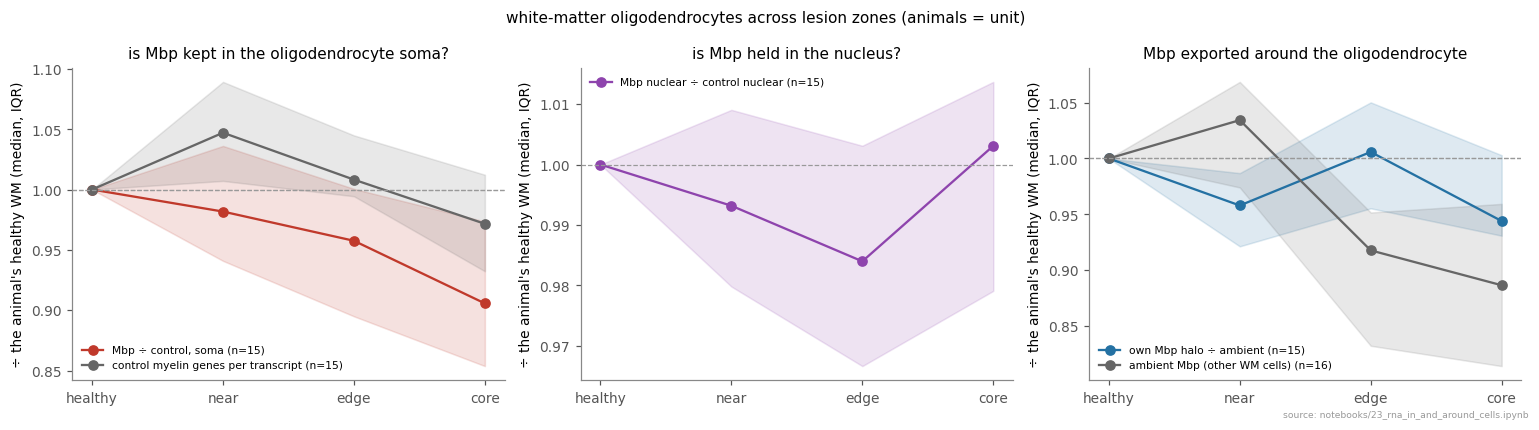

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
profile(axs[0], r_soma, "Mbp ÷ control, soma", "#c0392b")
profile(axs[0], r_ctrl, "control myelin genes per transcript", "0.4")
axs[0].set_title("is Mbp kept in the oligodendrocyte soma?")
profile(axs[1], r_nuc, "Mbp nuclear ÷ control nuclear", "#8e44ad")
axs[1].set_title("is Mbp held in the nucleus?")
profile(axs[2], r_halo, "own Mbp halo ÷ ambient", "#2471a3")
profile(axs[2], r_amb, "ambient Mbp (other WM cells)", "0.4")
axs[2].set_title("Mbp exported around the oligodendrocyte")
for ax in axs:
    ax.set_ylabel("÷ the animal's healthy WM (median, IQR)")
    ax.legend(fontsize=7)
fig.suptitle("white-matter oligodendrocytes across lesion zones (animals = unit)", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "q1_mbp_zone_profiles", OUT, SRC)

### Is it real? Section 1 under the confound checks
Each row repeats the core-vs-healthy contrast: the other lesion definition (curated niches), each run alone, each
segmentation method alone (outlines from 18S, the boundary stain or nucleus expansion capture the soma differently),
and each size third of the cells (small lesion oligodendrocytes could simply capture less perinuclear *Mbp*). Cells:
×ratio core ÷ healthy (median over animals), animals lower, Wilcoxon p.

In [11]:
def olz(fn, states=None):
    def f(s, by):
        o_ = s[s.Anno_L1_curated == "Oligodendrocyte"]
        if states:
            o_ = o_[o_.ctype.isin(states)]
        return per_zone(o_, fn, by=by)
    return f


def amb(s, by):
    return per_zone(s[~s.Anno_L1_curated.isin(["Oligodendrocyte", "OPC"])], ratio("halo_mbp", "halo_area"), by=by)


def own_halo(states=None):
    return lambda s, by: (olz(ratio("halo_mbp", "halo_area"), states)(s, by) / amb(s, by)).dropna()


r1 = pd.concat([robust(wm, olz(ratio("mbp_cell", "myelin_ctrl_cell")), "Mbp ÷ control, soma (all oligos)"),
                robust(wm, olz(ratio("mbp_cell", "myelin_ctrl_cell"), ["MOL"]), "Mbp ÷ control, soma (MOL only)"),
                robust(wm, own_halo(["NFOL"]), "own Mbp halo ÷ ambient (NFOL)"),
                robust(wm, amb, "ambient Mbp around other WM cells")])
r1.round(4).to_csv(OUT / "q1_robustness.csv", index=False)
fmt(r1)

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


...

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


readout,"Mbp ÷ control, soma (MOL only)","Mbp ÷ control, soma (all oligos)",ambient Mbp around other WM cells,own Mbp halo ÷ ambient (NFOL)
check,,,,
main: lesion-region zones,"×0.88 (13/14 lower, p=0.013)","×0.91 (12/15 lower, p=0.0067)","×0.89 (12/16 lower, p=0.018)","×0.91 (11/13 lower, p=0.0024)"
curated lesion niches vs physiological,"×0.96 (12/17 lower, p=0.011)","×0.94 (13/17 lower, p=0.0032)","×0.95 (13/18 lower, p=0.054)","×0.99 (11/16 lower, p=0.13)"
run5 only,"×0.85 (9/10 lower, p=0.084)","×0.89 (9/11 lower, p=0.024)","×0.88 (10/12 lower, p=0.0034)","×0.92 (7/9 lower, p=0.039)"
run6 only,"×0.91 (4/4 lower, p=nan)","×0.97 (3/4 lower, p=nan)","×1.00 (2/4 lower, p=nan)","×0.88 (4/4 lower, p=nan)"
segmented by interior stain (18S),"×0.88 (13/14 lower, p=0.013)","×0.92 (12/15 lower, p=0.018)","×0.89 (13/16 lower, p=0.0092)","×0.91 (11/13 lower, p=0.0046)"
segmented by nucleus expansion of 5.0µm,n/a,n/a,"×0.90 (2/3 lower, p=nan)",n/a
large cells (size third),"×0.85 (8/8 lower, p=0.0078)","×0.89 (12/14 lower, p=0.0017)","×0.91 (9/14 lower, p=0.091)","×0.85 (4/4 lower, p=nan)"
mid cells (size third),"×0.90 (11/12 lower, p=0.016)","×0.91 (12/14 lower, p=0.00085)","×0.92 (10/14 lower, p=0.12)","×0.90 (5/5 lower, p=0.062)"
small cells (size third),"×0.86 (9/12 lower, p=0.012)","×0.89 (12/14 lower, p=0.0012)","×0.88 (12/15 lower, p=0.015)","×0.93 (5/6 lower, p=0.16)"


**Per animal.** One line per animal from its healthy white matter to its lesion core (blue chronic, orange RR).

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q1_per_animal.png')

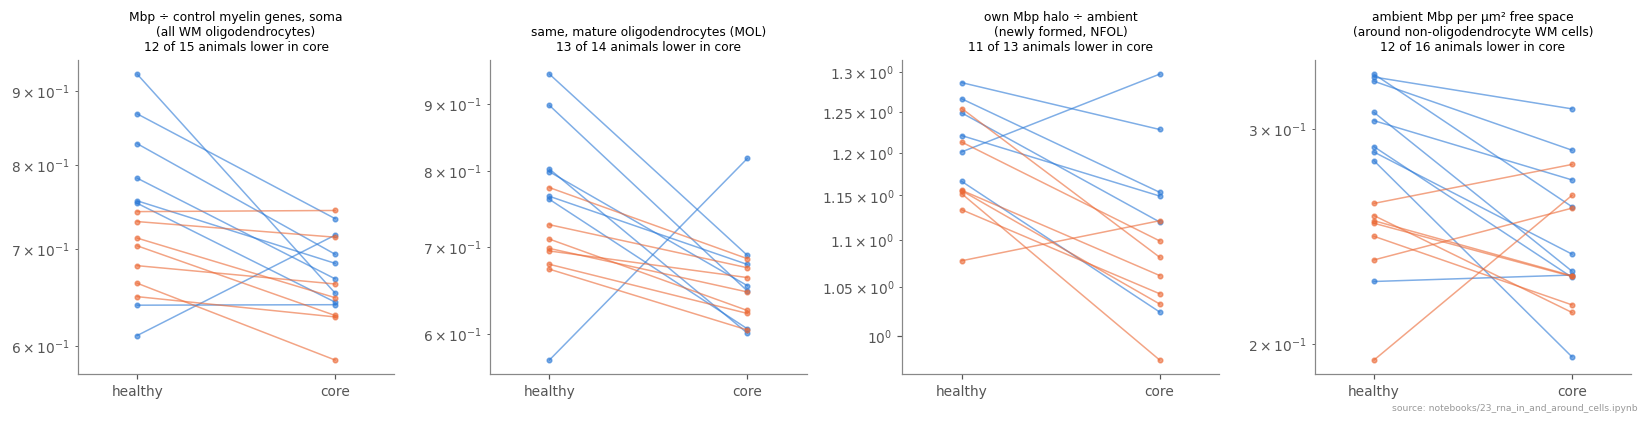

In [12]:
fig, axs = plt.subplots(1, 4, figsize=(15, 3.8))
paired_plot(axs[0], r_soma, "Mbp ÷ control myelin genes, soma\n(all WM oligodendrocytes)")
paired_plot(axs[1], olz(ratio("mbp_cell", "myelin_ctrl_cell"), ["MOL"])(wm, ("sample_name", "zone")),
            "same, mature oligodendrocytes (MOL)")
paired_plot(axs[2], own_halo(["NFOL"])(wm, ("sample_name", "zone")), "own Mbp halo ÷ ambient\n(newly formed, NFOL)")
paired_plot(axs[3], r_amb, "ambient Mbp per µm² free space\n(around non-oligodendrocyte WM cells)")
fig.tight_layout()
plotting.save_fig(fig, "q1_per_animal", OUT, SRC)

**Random oligodendrocytes, healthy vs lesion core.** Six random white-matter oligodendrocytes per row, one per random
animal (seed 0; not selected for the effect), 25 µm crops: the cell outlined in yellow, nuclei in blue, *Mbp* inside
outlines (red) and outside (cyan), control myelin genes (yellow dots).

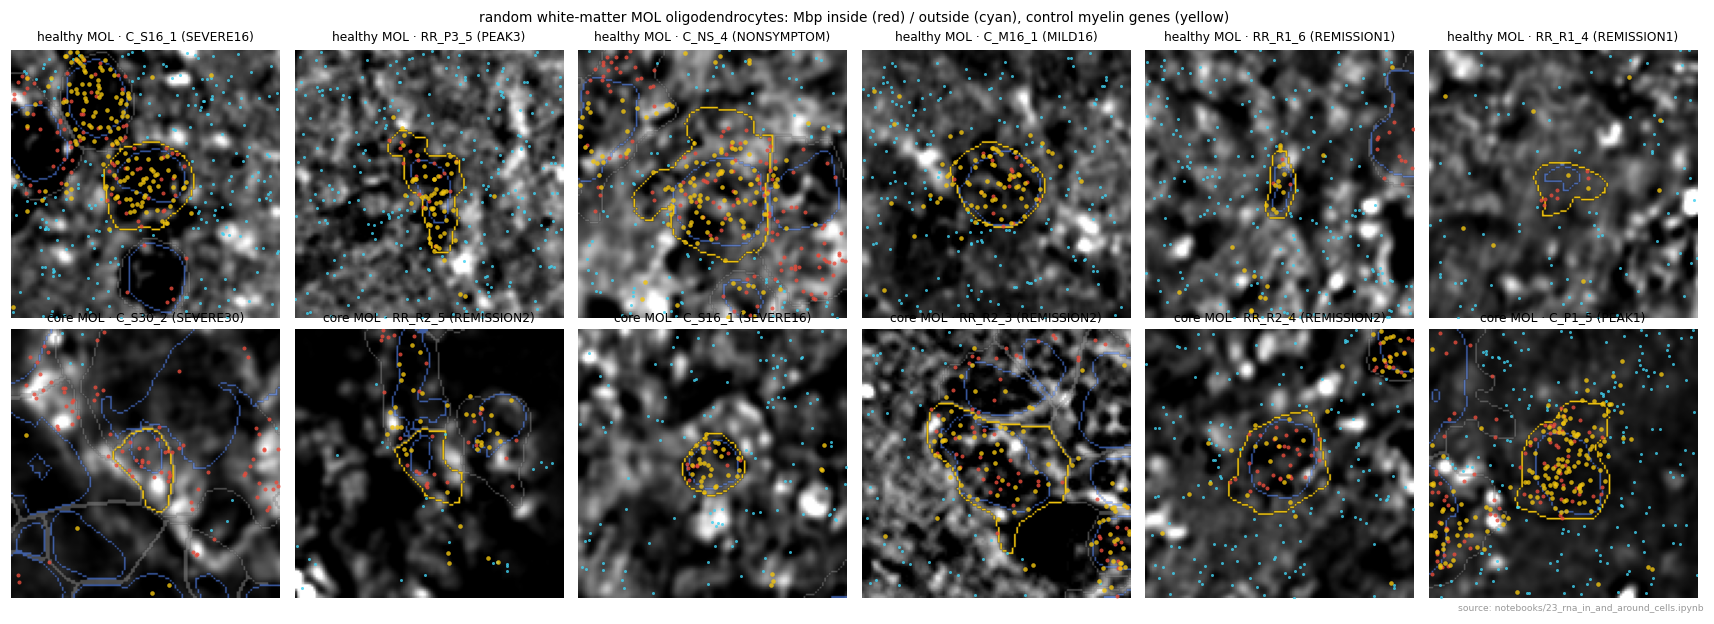

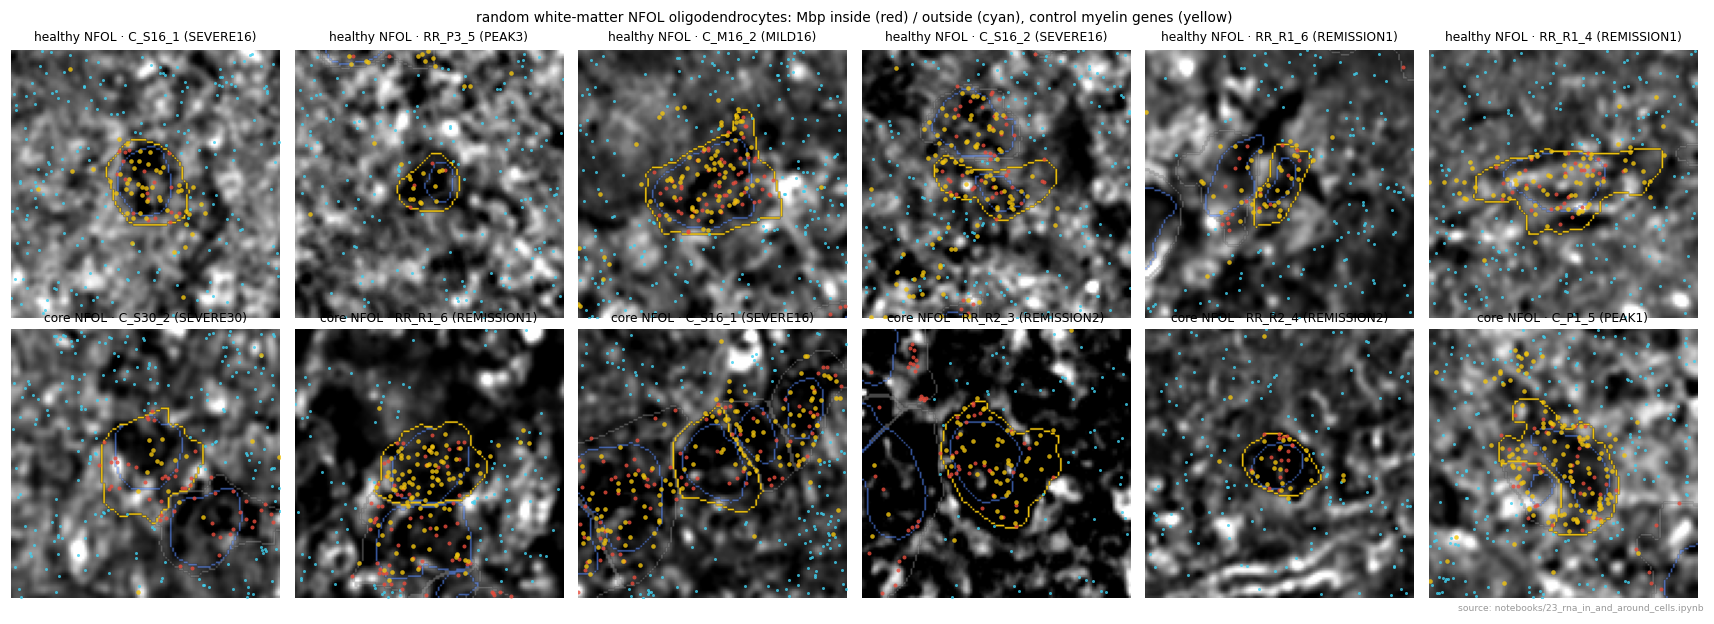

In [13]:
L1 = [(["Mbp"], False, "#3fd0f0", 4), (["Mbp"], True, "#e74c3c", 7), (SETS["myelin_ctrl"], None, "#f1c40f", 9)]
for st_ in ["MOL", "NFOL"]:
    o_ = ol[ol.ctype == st_]
    gallery([(f"healthy {st_}", o_[o_.zone == "healthy"]), (f"core {st_}", o_[o_.zone == "core"])], 25, L1,
            suptitle=f"random white-matter {st_} oligodendrocytes: Mbp inside (red) / outside (cyan), control myelin "
                     f"genes (yellow)", name=f"q1_gallery_{st_}")

**Seeing it.** Healthy vs lesion-core white matter of the same piece (the animal with the most core-zone
oligodendrocytes): ATP1A1/CD45/E-cad channel (grey), cell outlines (thin), oligodendrocytes outlined in yellow, *Mbp*
transcripts inside an outline (red) and outside (cyan), control myelin genes (yellow dots).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q1_mbp_crops.png')

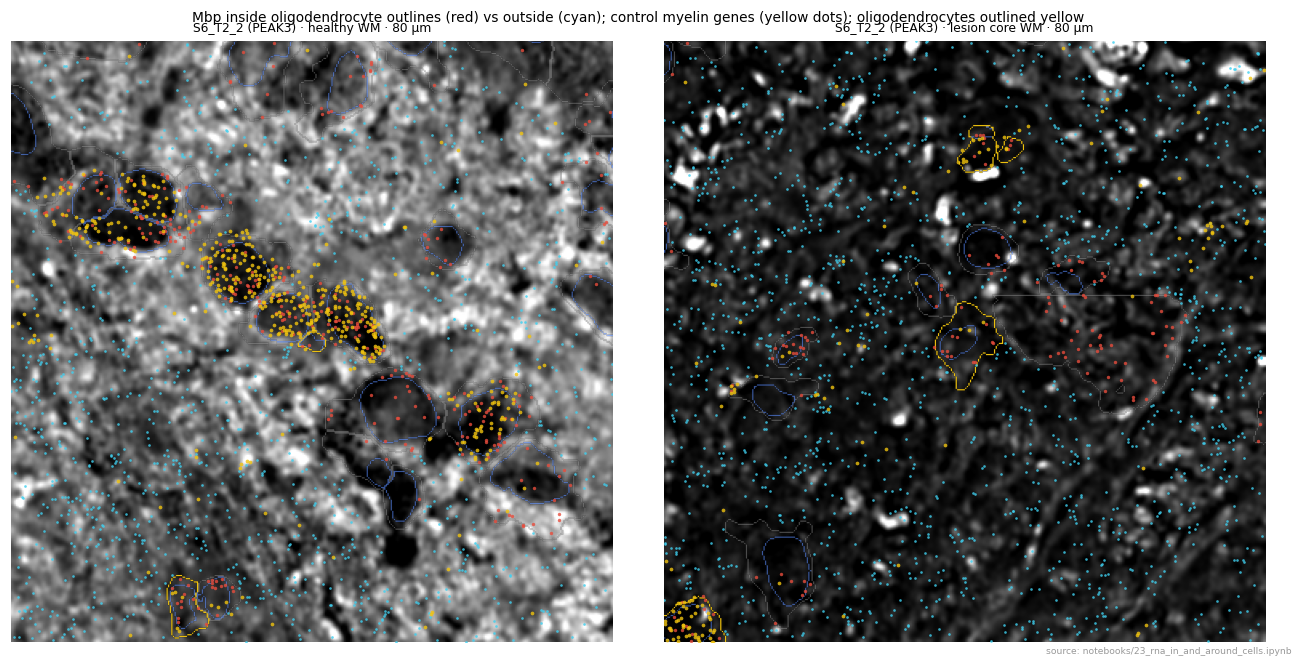

In [14]:
cnt = ol[ol.zone == "core"].groupby("meta_sample_id").size()
pc = cnt.idxmax()
g = ol[ol.meta_sample_id == pc]
rng = np.random.default_rng(0)
picks = [("healthy WM", g[g.zone == "healthy"]), ("lesion core WM", g[g.zone == "core"])]
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
W = 80
for ax, (lab_, s) in zip(axs, picks):
    r = s.iloc[rng.integers(len(s))]
    near = g[(g.x_centroid - r.x_centroid).abs().lt(W / 2) & (g.y_centroid - r.y_centroid).abs().lt(W / 2)]
    show_crop(ax, r, W, [(["Mbp"], False, "#3fd0f0", 3), (["Mbp"], True, "#e74c3c", 5),
                         (SETS["myelin_ctrl"], None, "#f1c40f", 6)],
              cell_hl=near.index.str.split(":").str[1], title=f"{pc} ({g.stage.iloc[0]}) · {lab_} · {W} µm")
fig.suptitle("Mbp inside oligodendrocyte outlines (red) vs outside (cyan); control myelin genes (yellow dots); "
             "oligodendrocytes outlined yellow", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "q1_mbp_crops", OUT, SRC)

## 2. What do macrophages and microglia carry inside them?
Myeloid cells (`ctype`: MDM, microglia, CAM) against non-phagocytic cells in the same zone (astrocytes, T cells,
endothelial cells). Two readouts:
- **Uptake ratio**: myelin transcripts per µm² inside the outline ÷ myelin transcripts per µm² of free space in the
  cell's own halo. Spillover from surrounding RNA gives similar ratios for all cell types of a similar size; a cell
  that has taken up myelin material has a higher one.
- **Depth**: share of the myelin transcripts in a cell that sit deep (>= 2 µm from the outline) rather than at the rim
  (< 1 µm), ÷ the same share for the cell's own marker RNA (phagocyte genes for myeloid cells, astrocyte genes for
  astrocytes). Spillover sits at the rim (ratio well below 1); engulfed material spreads like the cell's own RNA
  (ratio near 1).

Plus a dose test within myeloid cells: uptake by *Cd68* level (lysosomal/phagocytic marker), tertiles within each
animal × zone. The same is done for neuron-derived RNA (neurofilaments, *Stmn2*, *Gap43*; mostly from grey matter, see the correction in section 4).

In [15]:
cells["myelin_cell"] = cells[[f"{k}_cell" for k in MYELIN]].sum(1)
cells["halo_myelin"] = cells[[f"halo_{k}" for k in MYELIN if f"halo_{k}" in cells]].sum(1)
for lay in ["rim", "deep"]:
    cells[f"{lay}_myelin"] = cells[[f"{lay}_{k}" for k in MYELIN if f"{lay}_{k}" in cells]].sum(1)
GROUPS = {"myeloid": ["MDM", "Microglia", "CAM"], "astrocyte": ["Reactive astro", "Homeostatic astro"],
          "T cell": ["T cell"], "endothelial": ["Endothelial"]}
cells["grp"] = None
for k, v in GROUPS.items():
    cells.loc[cells.ctype.isin(v), "grp"] = k


def uptake(mat):
    return lambda g: ((g[f"{mat}_cell"].sum() / g.cell_area.sum()) / (g[f"halo_{mat}"].sum() / g.halo_area.sum())
                      if g[f"halo_{mat}"].sum() > 0 else np.nan)


def depth_index(mat, own):
    def f(g):
        dm = g[f"deep_{mat}"].sum() / max(g[f"deep_{mat}"].sum() + g[f"rim_{mat}"].sum(), 1)
        do = g[f"deep_{own}"].sum() / max(g[f"deep_{own}"].sum() + g[f"rim_{own}"].sum(), 1)
        return dm / do if do > 0 else np.nan
    return f


up = {(grp, mat): per_zone(cells[cells.grp == grp], uptake(mat), by=("sample_name", "zone"))
      for grp in GROUPS for mat in ["myelin", "axon"]}
rows = []
for (grp, mat), v in up.items():
    w = v.unstack()
    for zn in ["healthy", "core"]:
        if zn in w:
            rows.append(dict(material=mat, cells=grp, zone=zn, animals=w[zn].notna().sum(),
                             uptake_median=w[zn].median()))
q2 = pd.DataFrame(rows).pivot_table(index=["material", "zone"], columns="cells", values="uptake_median").round(3)
q2.to_csv(OUT / "q2_uptake_by_celltype.csv")
q2

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


cells             T cell  astrocyte  endothelial  myeloid
material zone                                            
axon     core      0.836      1.055        0.685    1.090
         healthy   0.738      1.077        0.958    1.416
myelin   core      0.739      0.901        0.622    0.792
         healthy   0.843      0.906        0.830    1.045

Paired across animals within each zone: myeloid uptake ÷ astrocyte (and ÷ T cell) uptake, and the core-vs-healthy
change of the myeloid ratio.

In [16]:
rows = []
for mat in ["myelin", "axon"]:
    for ref in ["astrocyte", "T cell", "endothelial"]:
        rel = (up[("myeloid", mat)] / up[(ref, mat)]).replace([np.inf, -np.inf], np.nan).dropna()
        w = rel.unstack()
        for zn in ["healthy", "core"]:
            if zn in w:
                lf = np.log2(w[zn].dropna())
                rows.append(dict(material=mat, vs=ref, zone=zn, animals=len(lf), myeloid_over_ref=2 ** lf.median(),
                                 share_above=(lf > 0).mean(), p=wilcoxon(lf).pvalue if len(lf) >= 5 else np.nan))
        rows.append(dict(material=mat, vs=ref, zone="core ÷ healthy", **{
            k: v for k, v in contrast(rel).items() if k != "share_lower"}))
q2b = report(rows)
q2b.to_csv(OUT / "q2_myeloid_vs_reference.csv", index=False)
q2b

,material,vs,zone,animals,myeloid_over_ref,share_above,p,core_over_healthy
0,myelin,astrocyte,healthy,20,1.066,0.70,0.012,NaN
1,myelin,astrocyte,core,20,0.880,0.10,0.000,NaN
2,myelin,astrocyte,core ÷ healthy,15,NaN,NaN,0.000,0.848
3,myelin,T cell,healthy,2,1.301,0.50,NaN,NaN
4,myelin,T cell,core,20,1.113,0.70,0.004,NaN
5,myelin,T cell,core ÷ healthy,2,NaN,NaN,NaN,0.799
6,myelin,endothelial,healthy,20,1.214,0.90,0.000,NaN
7,myelin,endothelial,core,20,1.237,0.80,0.003,NaN
8,myelin,endothelial,core ÷ healthy,15,NaN,NaN,0.000,1.132
9,axon,astrocyte,healthy,20,1.248,1.00,0.000,NaN


In [17]:
my = cells[cells.grp == "myeloid"].copy()
my["cd68_level"] = my.cd68_cell / my.n_total.clip(lower=1)
my["cd68_tertile"] = my.groupby(["sample_name", "zone"]).cd68_level.transform(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=["low", "mid", "high"]) if len(s) >= 30 else np.nan)
rows = []
for zn in ["healthy", "edge", "core"]:
    s = my[my.zone == zn]
    for mat in ["myelin", "axon"]:
        v = per_zone(s, uptake(mat), by=("sample_name", "cd68_tertile"), min_cells=10).unstack()
        if {"low", "high"} <= set(v.columns):
            lf = np.log2(v.high / v.low).replace([np.inf, -np.inf], np.nan).dropna()
            rows.append(dict(zone=zn, material=mat, animals=len(lf), high_over_low_Cd68=2 ** lf.median(),
                             share_above=(lf > 0).mean(), p=wilcoxon(lf).pvalue if len(lf) >= 5 else np.nan))
q2c = report(rows)
q2c.to_csv(OUT / "q2_uptake_by_cd68.csv", index=False)
q2c

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


,zone,material,animals,high_over_low_Cd68,share_above,p
0,healthy,myelin,20,0.837,0.10,0.000
1,healthy,axon,20,0.912,0.20,0.007
2,edge,myelin,21,0.705,0.00,0.000
3,edge,axon,21,0.754,0.19,0.002
4,core,myelin,20,0.734,0.05,0.000
5,core,axon,20,0.735,0.25,0.004


In [18]:
di = {"myeloid": per_zone(cells[cells.grp == "myeloid"], depth_index("myelin", "phago")),
      "astrocyte": per_zone(cells[cells.grp == "astrocyte"], depth_index("myelin", "astro"))}
rows = [dict(cells=k, zone=zn, animals=v.unstack()[zn].notna().sum(), depth_index_median=v.unstack()[zn].median())
        for k, v in di.items() for zn in ["healthy", "edge", "core"] if zn in v.unstack()]
q2d = report(rows)
q2d.to_csv(OUT / "q2_depth_index.csv", index=False)
q2d

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


,cells,zone,animals,depth_index_median
0,myeloid,healthy,20,0.706
1,myeloid,edge,21,0.680
2,myeloid,core,20,0.628
3,astrocyte,healthy,20,0.767
4,astrocyte,edge,21,0.711
5,astrocyte,core,20,0.721


### Is it real? Section 2 under the confound checks
Here the claim is about the *level* in lesion cores, so each row compares myeloid cells with astrocytes **within the
core** (ratio = myeloid ÷ astrocyte; "lower" = myeloid lower), under the same checks. Then the *Cd68* result: are
*Cd68*-high myeloid cells simply bigger (so less RNA per µm²)? Per tertile: cell area, and myelin RNA per transcript
instead of per µm².

In [19]:
def vs_astro(mat):
    def f(s, by):
        s = s[s[by[1]] == "core"]
        m_ = per_zone(s[s.grp == "myeloid"], uptake(mat), by=("sample_name",))
        a_ = per_zone(s[s.grp == "astrocyte"], uptake(mat), by=("sample_name",))
        return pd.concat({"healthy": a_, "core": m_}).swaplevel().sort_index()
    return f


r2 = pd.concat([robust(cells, vs_astro("myelin"), "myelin uptake: myeloid ÷ astrocyte (core)"),
                robust(cells, vs_astro("axon"), "neuron-derived RNA uptake: myeloid ÷ astrocyte (core)")])
r2.round(4).to_csv(OUT / "q2_robustness.csv", index=False)
fmt(r2)

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


...

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

readout,myelin uptake: myeloid ÷ astrocyte (core),neuron-derived RNA uptake: myeloid ÷ astrocyte (core)
check,,
main: lesion-region zones,"×0.88 (18/20 lower, p=9.5e-06)","×0.97 (12/20 lower, p=0.52)"
curated lesion niches vs physiological,"×0.94 (17/24 lower, p=0.011)","×0.98 (14/24 lower, p=0.25)"
run5 only,"×0.90 (12/14 lower, p=0.00061)","×0.97 (9/14 lower, p=0.3)"
run6 only,"×0.87 (6/6 lower, p=0.031)","×1.03 (3/6 lower, p=0.69)"
segmented by boundary stain (ATP1A1+CD45+E-Cadherin),"×0.91 (1/2 lower, p=nan)","×0.65 (2/2 lower, p=nan)"
segmented by interior stain (18S),"×0.88 (18/20 lower, p=9.5e-06)","×0.97 (12/20 lower, p=0.5)"
segmented by nucleus expansion of 5.0µm,"×0.84 (3/3 lower, p=nan)","×0.99 (2/3 lower, p=nan)"
large cells (size third),"×0.88 (19/20 lower, p=1.3e-05)","×0.98 (11/20 lower, p=0.55)"
mid cells (size third),"×0.90 (16/20 lower, p=0.002)","×0.82 (15/20 lower, p=0.024)"


In [20]:
rows = []
for zn in ["healthy", "core"]:
    s = my[my.zone == zn]
    g = s.groupby(["sample_name", "cd68_tertile"], observed=True)
    t = pd.DataFrame({"area": g.cell_area.median(), "myelin_per_transcript": g.myelin_cell.sum() / g.n_total.sum(),
                      "transcripts": g.n_total.median()}).unstack()
    for c in ["area", "myelin_per_transcript", "transcripts"]:
        lf = np.log2(t[c]["high"] / t[c]["low"]).replace([np.inf, -np.inf], np.nan).dropna()
        rows.append(dict(zone=zn, measure=c, animals=len(lf), high_over_low_Cd68=2 ** lf.median(),
                         share_above=(lf > 0).mean(), p=wilcoxon(lf).pvalue if len(lf) >= 5 else np.nan))
q2e = report(rows)
q2e.to_csv(OUT / "q2_cd68_confounds.csv", index=False)
q2e

,zone,measure,animals,high_over_low_Cd68,share_above,p
0,healthy,area,20,1.271,0.85,0.000
1,healthy,myelin_per_transcript,20,0.817,0.25,0.006
2,healthy,transcripts,20,1.418,0.95,0.000
3,core,area,20,1.218,1.00,0.000
4,core,myelin_per_transcript,20,0.602,0.00,0.000
5,core,transcripts,20,1.471,1.00,0.000


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q2_per_animal.png')

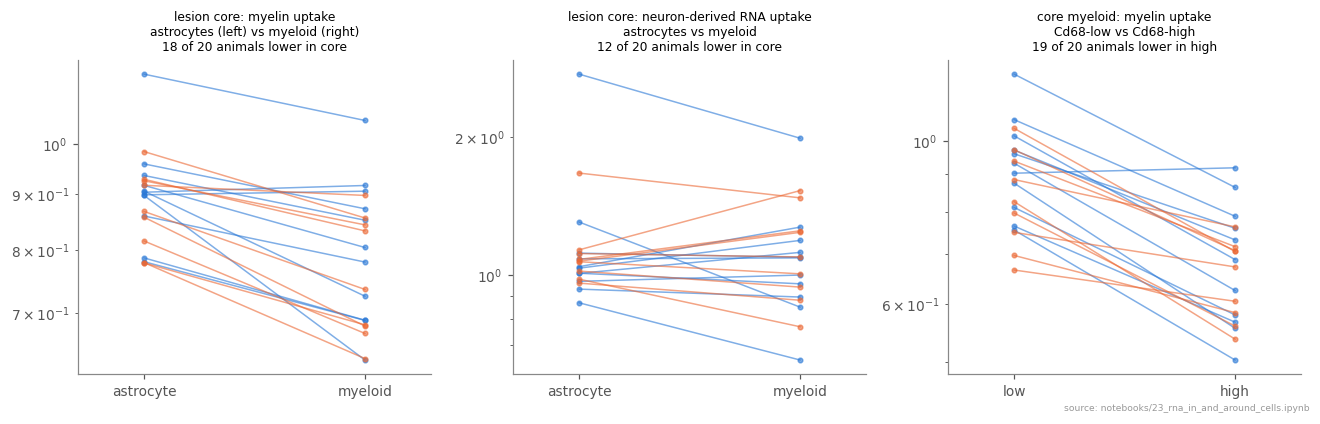

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8))
paired_plot(axs[0], vs_astro("myelin")(cells, ("sample_name", "zone")).rename(lambda x: x, level=1),
            "lesion core: myelin uptake\nastrocytes (left) vs myeloid (right)")
axs[0].set_xticks([0, 1], ["astrocyte", "myeloid"])
paired_plot(axs[1], vs_astro("axon")(cells, ("sample_name", "zone")), "lesion core: neuron-derived RNA uptake\nastrocytes vs myeloid")
axs[1].set_xticks([0, 1], ["astrocyte", "myeloid"])
v = per_zone(my[my.zone == "core"], uptake("myelin"), by=("sample_name", "cd68_tertile"), min_cells=10)
v = v.unstack()[["low", "high"]].stack().rename_axis(["sample_name", "zone"])
paired_plot(axs[2], v, "core myeloid: myelin uptake\nCd68-low vs Cd68-high", a="low", b="high")
fig.tight_layout()
plotting.save_fig(fig, "q2_per_animal", OUT, SRC)

**Random cells, lesion core.** Six random core myeloid cells and six random core astrocytes (one per random animal,
seed 0), 30 µm crops: the cell outlined in yellow, nuclei blue, myelin RNA inside outlines (red) and outside (cyan),
phagocyte genes (green), astrocyte genes (violet).

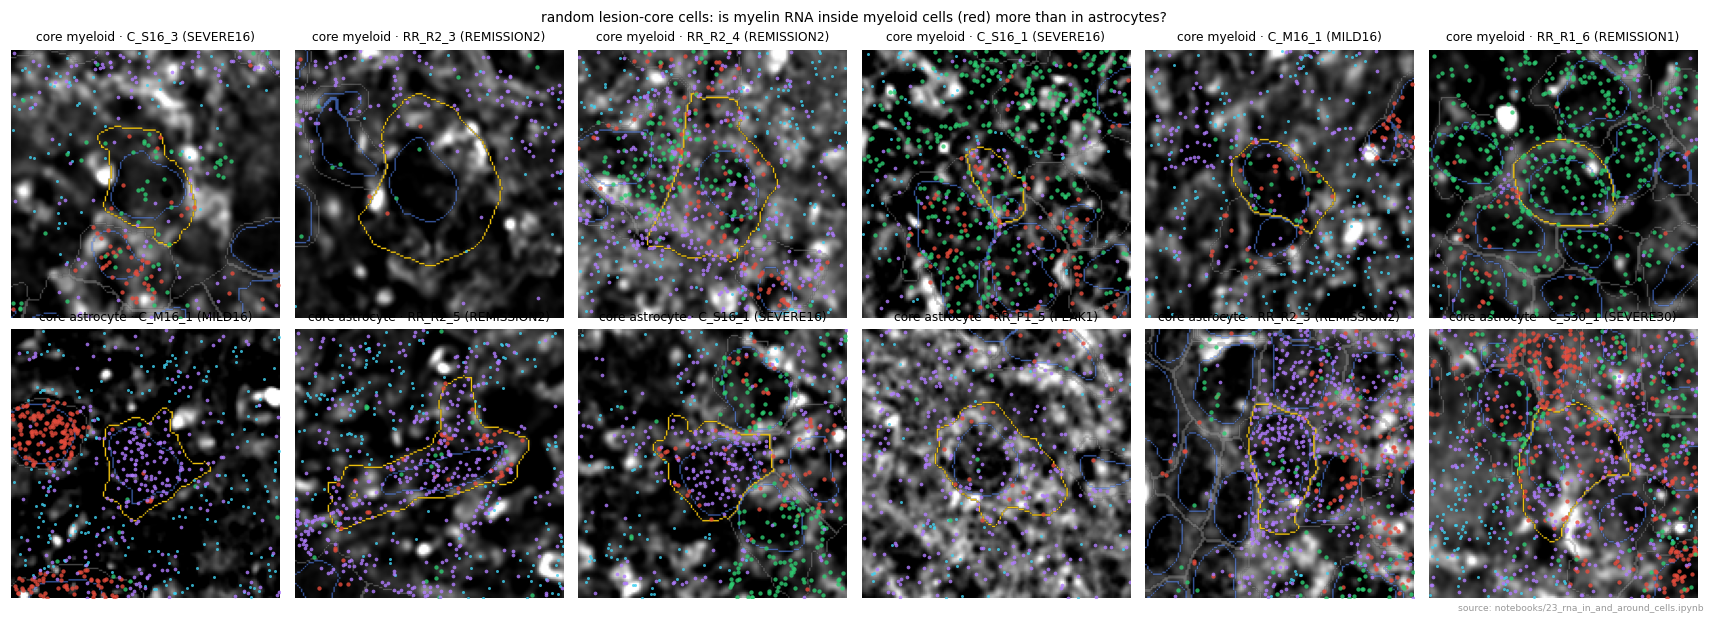

In [22]:
myel = [g for k in MYELIN for g in SETS[k]]
L2 = [(myel, False, "#3fd0f0", 4), (myel, True, "#e74c3c", 8), (SETS["phago"] + ["Cd68"], None, "#2ecc71", 8),
      (SETS["astro"], None, "#b07cff", 6)]
gallery([("core myeloid", cells[(cells.grp == "myeloid") & (cells.zone == "core")]),
         ("core astrocyte", cells[(cells.grp == "astrocyte") & (cells.zone == "core")])], 30, L2,
        suptitle="random lesion-core cells: is myelin RNA inside myeloid cells (red) more than in astrocytes?",
        name="q2_gallery_random")

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q2_uptake_profiles.png')

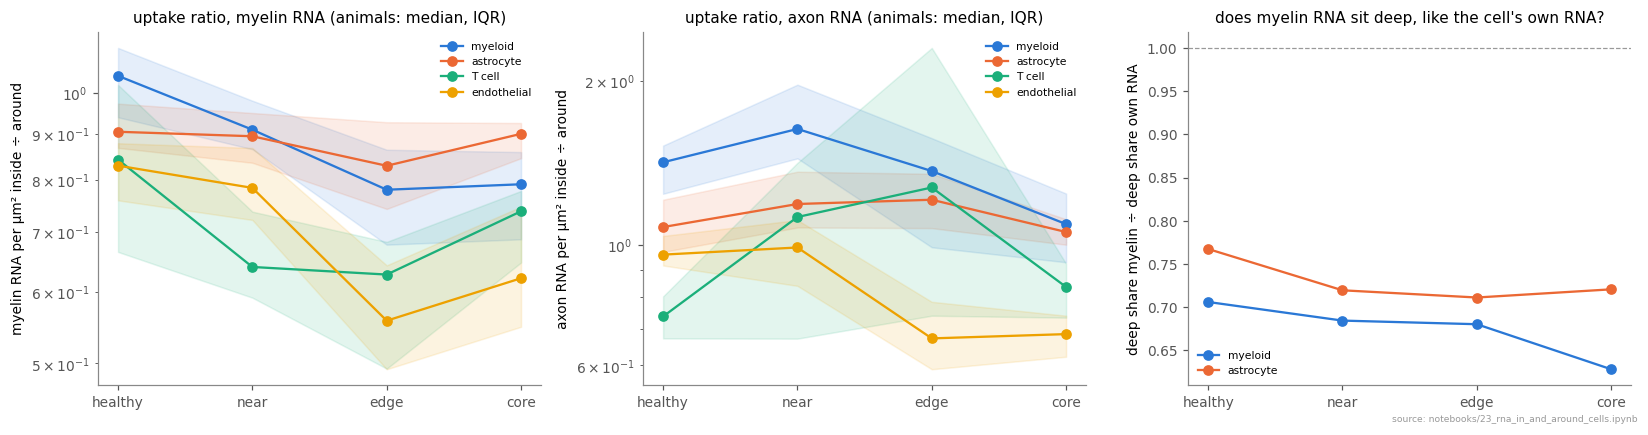

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.9))
for ax, mat in zip(axs[:2], ["myelin", "axon"]):
    for k, colr in zip(GROUPS, COL):
        w = up[(k, mat)].unstack().reindex(columns=ZONES)
        x = np.arange(len(ZONES))
        ax.plot(x, w.median(), marker="o", color=colr, label=k)
        ax.fill_between(x, w.quantile(0.25), w.quantile(0.75), color=colr, alpha=0.12)
    ax.set_xticks(np.arange(len(ZONES)), ZONES)
    ax.set_yscale("log")
    ax.set_ylabel(f"{mat} RNA per µm² inside ÷ around")
    ax.set_title(f"uptake ratio, {mat} RNA (animals: median, IQR)")
    ax.legend(fontsize=7)
for k, colr in zip(di, COL):
    w = di[k].unstack().reindex(columns=ZONES)
    axs[2].plot(np.arange(len(ZONES)), w.median(), marker="o", color=colr, label=k)
axs[2].set_xticks(np.arange(len(ZONES)), ZONES)
axs[2].axhline(1, color="0.6", ls="--", lw=0.8)
axs[2].set_ylabel("deep share myelin ÷ deep share own RNA")
axs[2].set_title("does myelin RNA sit deep, like the cell's own RNA?")
axs[2].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "q2_uptake_profiles", OUT, SRC)

**Seeing it.** Myeloid cells in lesion cores with the highest myelin uptake ratio (>= 20 myelin transcripts; one per
animal, top 4 animals): ATP1A1/CD45/E-cad channel, the myeloid cell outlined in yellow, myelin transcripts inside
(red) and outside (cyan) its outline, phagocyte genes (green).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q2_myeloid_crops.png')

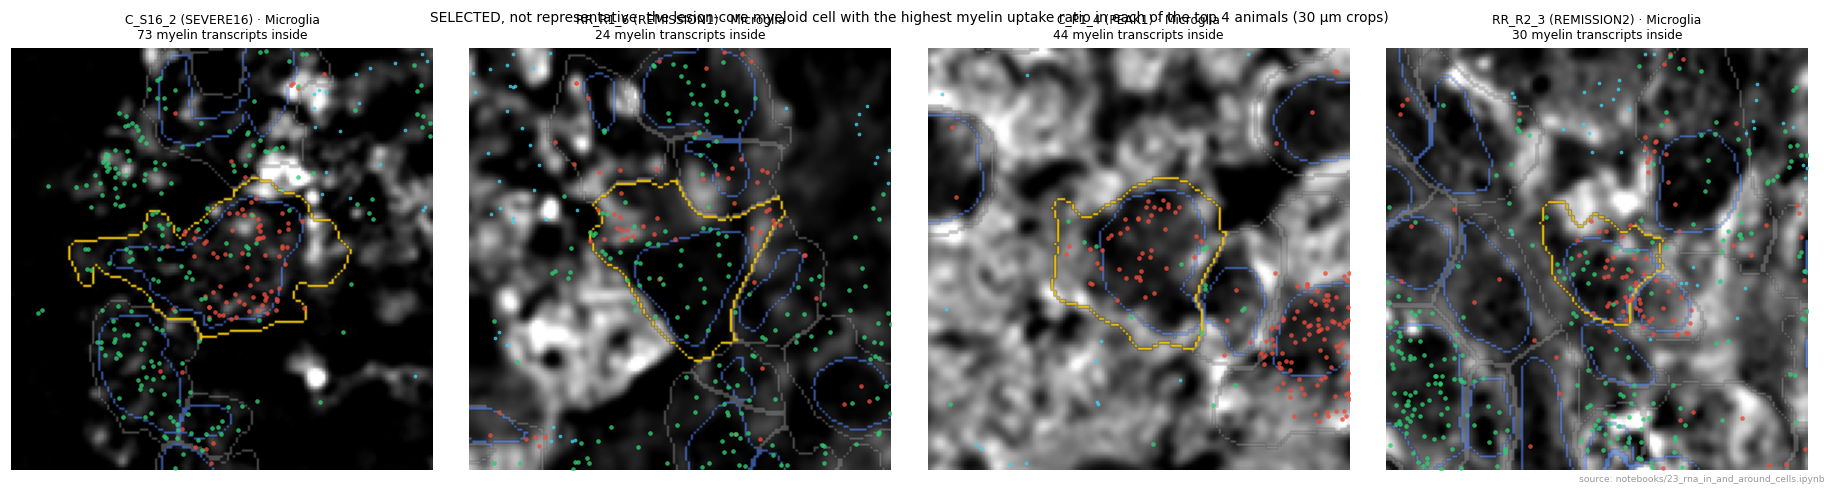

In [24]:
cand = my[(my.zone == "core") & (my.myelin_cell >= 20)].copy()
cand["u"] = (cand.myelin_cell / cand.cell_area) / ((cand.halo_myelin + 1) / cand.halo_area.clip(lower=1))
top = cand.sort_values("u", ascending=False).drop_duplicates("sample_name").head(4)
fig, axs = plt.subplots(1, len(top), figsize=(4.2 * len(top), 4.4))
for ax, (_, r) in zip(np.atleast_1d(axs), top.iterrows()):
    myel = [g for k in MYELIN for g in SETS[k]]
    show_crop(ax, r, 30, [(myel, False, "#3fd0f0", 6), (myel, True, "#e74c3c", 9), (SETS["phago"] + ["Cd68"], None,
                                                                                    "#2ecc71", 9)],
              cell_hl=[r.name.split(":")[1]], title=f"{r.sample_name} ({r.stage}) · {r.ctype}\n"
                                                    f"{int(r.myelin_cell)} myelin transcripts inside")
fig.suptitle("SELECTED, not representative: the lesion-core myeloid cell with the highest myelin uptake ratio in each of "
             "the top 4 animals (30 µm crops)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "q2_myeloid_crops", OUT, SRC)

## 3. Do lesion cells hold their RNA back in the nucleus?
The nuclear share of a cell's transcripts depends on how much of the outline the nucleus covers. So per animal ×
zone × cell type: **nuclear share of transcripts ÷ nuclear share of area** (pooled). Above 1 = RNA concentrated in
the nucleus beyond its footprint. Core vs healthy across animals, for each major cell type; then which genes shift
most (relative nuclear share: a gene's nuclear share ÷ the nuclear share of all transcripts in the same cells, so
shape changes cancel).

In [25]:
TYPES = ["Oligodendrocyte", "Myeloid", "Astrocyte", "Neuron", "Endothelial", "Fibroblast", "OPC", "T cell"]
rows, nucz = [], {}
for t in TYPES:
    s = cells[cells.Anno_L1_curated == t]
    v = per_zone(s, lambda g: (g.n_nuc.sum() / g.n_total.sum()) / (g.nucleus_area.sum() / g.cell_area.sum()))
    ar = per_zone(s, ratio("nucleus_area", "cell_area"))
    nucz[t] = v
    rows.append(dict(cell_type=t, readout="nuclear RNA share ÷ nuclear area share", **contrast(v)))
    rows.append(dict(cell_type=t, readout="nuclear area share (geometry)", **contrast(ar)))
q3 = report(rows)
q3["fdr"] = np.nan
m = q3.p.notna()
q3.loc[m, "fdr"] = multipletests(q3.loc[m, "p"], method="fdr_bh")[1].round(4)
q3.to_csv(OUT / "q3_nuclear_retention.csv", index=False)
q3

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


...

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

,cell_type,readout,animals,core_over_healthy,share_lower,p,fdr
0,Oligodendrocyte,nuclear RNA share ÷ nuclear area share,15,1.030,0.067,0.000,0.0000
1,Oligodendrocyte,nuclear area share (geometry),15,0.979,0.933,0.007,0.0122
2,Myeloid,nuclear RNA share ÷ nuclear area share,15,1.022,0.333,0.121,0.1694
3,Myeloid,nuclear area share (geometry),15,0.926,0.933,0.005,0.0117
4,Astrocyte,nuclear RNA share ÷ nuclear area share,15,1.020,0.400,0.169,0.2151
5,Astrocyte,nuclear area share (geometry),15,0.947,0.667,0.048,0.0747
6,Neuron,nuclear RNA share ÷ nuclear area share,12,0.992,0.583,0.470,0.5062
7,Neuron,nuclear area share (geometry),12,0.782,0.917,0.001,0.0035
8,Endothelial,nuclear RNA share ÷ nuclear area share,16,0.997,0.500,0.528,0.5280
9,Endothelial,nuclear area share (geometry),16,1.081,0.250,0.003,0.0084


In [26]:
pk = pool.key.str.split("|", expand=True)
pk.columns = ["animal", "type", "zone"]
SCREEN_TYPES = ["MOL", "NFOL", "DAO", "OPC/COP", "Microglia", "MDM", "Reactive astro", "Homeostatic astro",
                "Endothelial", "Fibroblast", "Exc neuron", "Inh neuron"]
rows = []
for t in SCREEN_TYPES:
    res = {}
    for zn in ["healthy", "core"]:
        m = ((pk.type == t) & (pk.zone == zn)).to_numpy()
        T, N = pool_tot[m], pool_nuc[m]
        rel = (N / np.where(T > 0, T, np.nan)) / (N.sum(1, keepdims=True) / T.sum(1, keepdims=True))
        rel[T < 30] = np.nan
        res[zn] = pd.DataFrame(rel, index=pk.animal[m].to_numpy(), columns=genes)
    an = res["healthy"].index.intersection(res["core"].index)
    if len(an) < 6:
        continue
    lf = np.log2(res["core"].loc[an] / res["healthy"].loc[an])
    ok = lf.notna().sum() >= 6
    for g in genes[ok.to_numpy()]:
        x = lf[g].dropna()
        x = x[np.isfinite(x)]
        if len(x) >= 6:
            rows.append(dict(cell_type=t, gene=g, animals=len(x), core_over_healthy=2 ** x.median(),
                             share_higher=(x > 0).mean(), p=wilcoxon(x).pvalue))
scr = pd.DataFrame(rows)
scr["fdr"] = scr.groupby("cell_type").p.transform(lambda p: multipletests(p, method="fdr_bh")[1])
scr.to_csv(OUT / "q3_gene_screen.csv", index=False)
print(scr.groupby("cell_type").apply(lambda d: pd.Series(dict(genes=len(d), fdr05=(d.fdr < 0.05).sum(),
                                                             up=((d.fdr < 0.05) & (d.core_over_healthy > 1)).sum()))))
scr[scr.fdr < 0.05].sort_values("p").groupby("cell_type").head(8).round(4)

/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


                   genes  fdr05   up
cell_type                           
DAO                  565      4    2
Endothelial         1871    608  185
Exc neuron           482      0    0
Fibroblast          1656     33   15
Homeostatic astro    911     49   24
Inh neuron          1070      0    0
MOL                 1519     10    4
Microglia           1888    738  350
NFOL                 444      0    0
OPC/COP             1093     62   41
Reactive astro       905     33   16


/tmp/ipykernel_2611/3833555081.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(scr.groupby("cell_type").apply(lambda d: pd.Series(dict(genes=len(d), fdr05=(d.fdr < 0.05).sum(),


,cell_type,gene,animals,core_over_healthy,share_higher,p,fdr
9290,Fibroblast,Apod,20,1.1803,1.0000,0.0000,0.0021
9901,Fibroblast,Igf2,19,1.1591,1.0000,0.0000,0.0021
10529,Fibroblast,Serping1,20,1.0964,0.9500,0.0000,0.0021
9372,Fibroblast,Bmp1,18,0.8374,0.0000,0.0000,0.0021
10615,Fibroblast,Sorbs1,18,0.6521,0.0000,0.0000,0.0021
10805,Fibroblast,Vtn,18,1.1910,1.0000,0.0000,0.0021
10314,Fibroblast,Plec,18,0.8940,0.0556,0.0000,0.0036
8029,Endothelial,H2-D1,17,0.8744,0.0000,0.0000,0.0013
10419,Fibroblast,Rab7,19,1.0834,0.8947,0.0000,0.0039
4328,Microglia,H2-D1,16,0.8585,0.0000,0.0000,0.0008


In [27]:
scr[scr.gene.isin(SETS["stress"])].sort_values(["gene", "cell_type"]).round(3)

,cell_type,gene,animals,core_over_healthy,share_higher,p,fdr
2008,DAO,Atf4,7,1.007,0.714,0.688,0.966
7477,Endothelial,Atf4,15,1.001,0.533,0.359,0.507
10901,Exc neuron,Atf4,9,0.956,0.444,0.496,0.923
9322,Fibroblast,Atf4,16,0.939,0.312,0.433,0.772
6487,Homeostatic astro,Atf4,9,1.202,0.667,0.098,0.325
11415,Inh neuron,Atf4,12,0.924,0.250,0.092,0.499
126,MOL,Atf4,13,1.009,0.538,0.839,0.958
3765,Microglia,Atf4,15,1.021,0.667,0.035,0.079
1556,NFOL,Atf4,6,1.182,0.833,0.156,0.593
2618,OPC/COP,Atf4,14,1.027,0.571,0.670,0.868


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q3_nuclear_retention.png')

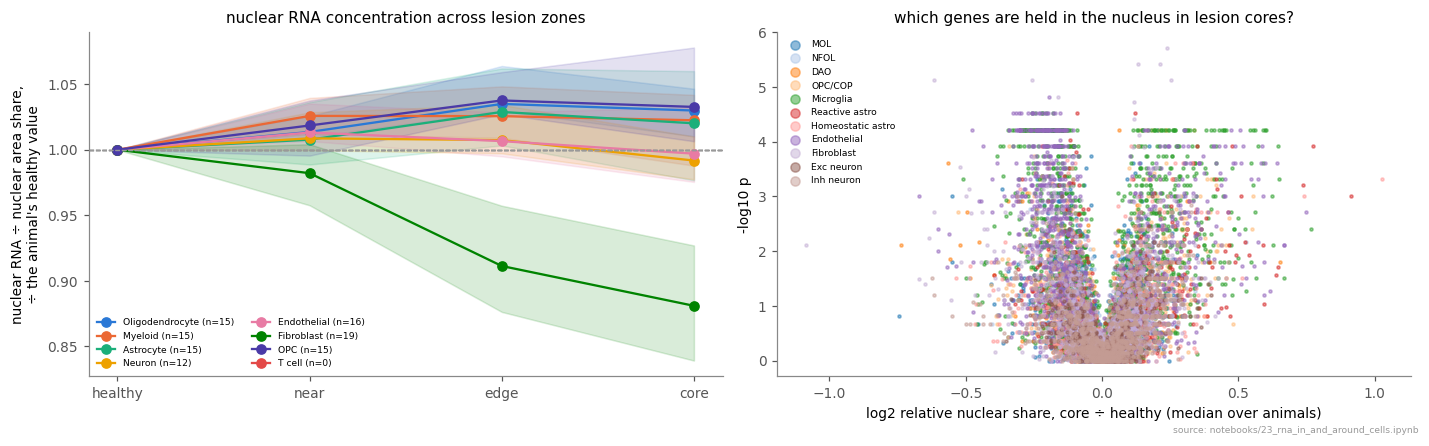

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for t, colr in zip(TYPES, COL):
    profile(axs[0], nucz[t], t, colr)
axs[0].set_ylabel("nuclear RNA ÷ nuclear area share,\n÷ the animal's healthy value")
axs[0].set_title("nuclear RNA concentration across lesion zones")
axs[0].legend(fontsize=6, ncol=2)
for i, t in enumerate(SCREEN_TYPES):
    d = scr[scr.cell_type == t]
    if len(d):
        axs[1].scatter(np.log2(d.core_over_healthy), -np.log10(d.p), s=4, color=plt.cm.tab20(i), alpha=0.5, label=t)
axs[1].set_xlabel("log2 relative nuclear share, core ÷ healthy (median over animals)")
axs[1].set_ylabel("-log10 p")
axs[1].set_title("which genes are held in the nucleus in lesion cores?")
axs[1].legend(fontsize=6, markerscale=3)
fig.tight_layout()
plotting.save_fig(fig, "q3_nuclear_retention", OUT, SRC)

**Does it follow disease severity?** Per animal, nuclear retention in the core ÷ healthy (log2), against the clinical
score at sacrifice and the first-attack peak (Spearman; exploratory, n = animals with lesion cores).

In [29]:
rows = []
for t in TYPES:
    w = nucz[t].unstack()
    if not {"core", "healthy"} <= set(w.columns):
        continue
    lf = np.log2(w.core / w.healthy).dropna().rename("lf").to_frame().join(clin[["score", "first_peak", "auc"]])
    for c in ["score", "first_peak", "auc"]:
        x = lf[["lf", c]].dropna()
        if len(x) >= 8:
            r = spearmanr(x.lf, x[c])
            rows.append(dict(cell_type=t, clinical=c, animals=len(x), rho=r.statistic, p=r.pvalue))
q3c = report(rows)
q3c.to_csv(OUT / "q3_vs_clinical.csv", index=False)
q3c

,cell_type,clinical,animals,rho,p
0,Oligodendrocyte,score,15,0.371,0.173
1,Oligodendrocyte,first_peak,15,0.284,0.305
2,Oligodendrocyte,auc,15,0.189,0.499
3,Myeloid,score,15,0.303,0.272
4,Myeloid,first_peak,15,0.208,0.457
5,Myeloid,auc,15,0.232,0.405
6,Astrocyte,score,15,0.362,0.184
7,Astrocyte,first_peak,15,0.048,0.864
8,Astrocyte,auc,15,0.229,0.413
9,Neuron,score,12,-0.032,0.920


### Is it real? Section 3 under the confound checks
Nuclear share depends on how the outline was drawn (18S, boundary stain, nucleus expansion) and on cell size, so
each is checked alone; MOL only removes the shift in oligodendrocyte state between zones.

In [30]:
nucx = lambda g: (g.n_nuc.sum() / g.n_total.sum()) / (g.nucleus_area.sum() / g.cell_area.sum())
r3 = pd.concat([robust(cells[cells.Anno_L1_curated == t], zf(nucx), t) for t in ["Oligodendrocyte", "OPC", "Myeloid",
                                                                                 "Astrocyte"]]
               + [robust(cells[cells.ctype == "MOL"], zf(nucx), "MOL only")])
r3.round(4).to_csv(OUT / "q3_robustness.csv", index=False)
fmt(r3)

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

...

/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)
/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


/tmp/ipykernel_2611/1454877800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v = g.apply(fn)


readout,Astrocyte,MOL only,Myeloid,OPC,Oligodendrocyte
check,,,,,
main: lesion-region zones,"×1.02 (6/15 lower, p=0.17)","×1.02 (3/15 lower, p=0.015)","×1.02 (5/15 lower, p=0.12)","×1.03 (3/15 lower, p=0.0067)","×1.03 (1/15 lower, p=0.00012)"
curated lesion niches vs physiological,"×1.04 (3/22 lower, p=9.9e-05)","×1.03 (2/21 lower, p=4.1e-05)","×0.97 (17/22 lower, p=0.0032)","×1.05 (1/18 lower, p=2.3e-05)","×1.03 (2/23 lower, p=1.2e-06)"
run5 only,"×1.00 (6/11 lower, p=0.76)","×1.02 (3/11 lower, p=0.12)","×1.03 (3/11 lower, p=0.15)","×1.02 (3/11 lower, p=0.067)","×1.03 (1/11 lower, p=0.002)"
run6 only,"×1.06 (0/4 lower, p=nan)","×1.04 (0/4 lower, p=nan)","×1.00 (2/4 lower, p=nan)","×1.06 (0/4 lower, p=nan)","×1.03 (0/4 lower, p=nan)"
segmented by interior stain (18S),"×1.03 (4/15 lower, p=0.015)","×1.02 (2/15 lower, p=0.0067)","×1.04 (1/15 lower, p=0.00018)","×1.04 (2/15 lower, p=0.00043)","×1.03 (1/15 lower, p=0.00012)"
segmented by nucleus expansion of 5.0µm,NaN,NaN,"×0.88 (3/4 lower, p=nan)",NaN,"×0.98 (1/1 lower, p=nan)"
large cells (size third),"×1.00 (7/15 lower, p=0.98)","×1.02 (4/11 lower, p=0.15)","×1.02 (7/15 lower, p=1)","×1.00 (5/11 lower, p=0.24)","×1.02 (3/15 lower, p=0.022)"
mid cells (size third),"×1.02 (5/15 lower, p=0.035)","×1.03 (2/13 lower, p=0.0017)","×1.03 (2/15 lower, p=0.022)","×1.03 (0/10 lower, p=0.002)","×1.03 (1/15 lower, p=0.00031)"
small cells (size third),"×1.03 (5/14 lower, p=0.058)","×1.02 (4/13 lower, p=0.057)","×1.00 (7/15 lower, p=0.19)","×1.04 (4/10 lower, p=0.11)","×1.04 (2/15 lower, p=0.0012)"


**Per animal and per cell.** Left: one line per animal (nuclear RNA share ÷ nuclear area share). Right: per-cell
distribution of the same quantity (log odds of a transcript being nuclear minus log odds of nuclear area), healthy vs
core oligodendrocytes, pooled over animals: a small shift of the whole distribution, or a subset of cells?

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q3_per_animal.png')

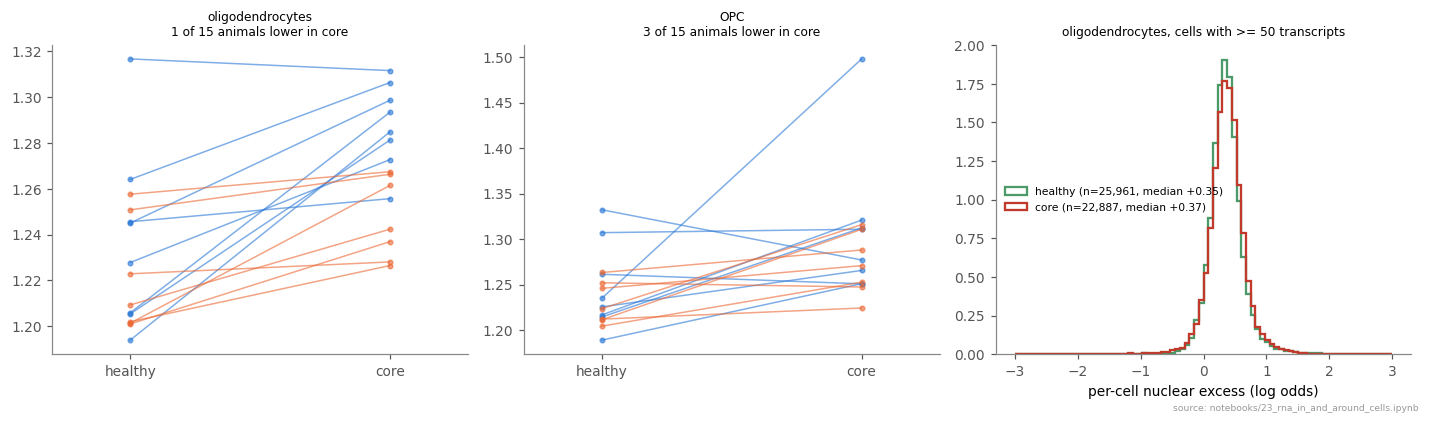

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
paired_plot(axs[0], nucz["Oligodendrocyte"], "oligodendrocytes", log=False)
paired_plot(axs[1], nucz["OPC"], "OPC", log=False)
o_ = cells[(cells.Anno_L1_curated == "Oligodendrocyte") & cells.zone.isin(["healthy", "core"]) & (cells.n_total >= 50)]
fr = ((o_.n_nuc + 0.5) / (o_.n_total + 1)).clip(1e-3, 1 - 1e-3)
ar = (o_.nucleus_area / o_.cell_area).clip(1e-3, 1 - 1e-3)
ex = np.log(fr / (1 - fr)) - np.log(ar / (1 - ar))
for zn, colr in [("healthy", ZCOL["healthy"]), ("core", ZCOL["core"])]:
    x = ex[o_.zone == zn]
    axs[2].hist(x, bins=80, range=(-3, 3), density=True, histtype="step", color=colr, lw=1.5,
                label=f"{zn} (n={len(x):,}, median {x.median():+.2f})")
axs[2].set_xlabel("per-cell nuclear excess (log odds)")
axs[2].legend(fontsize=7)
axs[2].set_title("oligodendrocytes, cells with >= 50 transcripts", fontsize=8)
fig.tight_layout()
plotting.save_fig(fig, "q3_per_animal", OUT, SRC)

## 4. What does the space between cells lose in white-matter lesions?
RNA outside cell outlines in white matter, per µm² of free space within 10 µm of a cell: myelin RNA (*Mbp* and the
other myelin genes), neuron-derived RNA (neurofilaments, *Stmn2*, *Gap43*; mostly from grey matter, see the correction in section 4), astrocyte RNA (*Gfap*, *Aqp4*, …) and all genes.
**Local comparison as in notebook 20:** within each piece, white-matter cells of curated lesion niches against
physiological-niche WM cells within 150 µm of them (the comparison behind the ×0.83 ATP1A1 neuropil loss), so tract
anatomy can't drive the difference. Next to it, the ATP1A1 neuropil index of the same cells (notebook 20 definition),
so protein and RNA loss can be compared piece by piece. Checks: the lesion-region zones instead (core vs healthy WM,
which by definition lies > 150 µm away, so within 400 µm), and each run alone. "Free space" = area within 10 µm of a
cell that lies outside every outline; less of it in crowded lesions is why densities are per µm² of free space.

In [32]:
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["segmentation_method", "bnd_terr_mean", "bnd_scale", "bnd_bg_local"])
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]
raw = fa.bnd_terr_mean * fa.bnd_scale + fa.bnd_bg_local
w4 = cells[cells.wm].join(raw.rename("atp_raw"))
w4["atp_index"] = w4.atp_raw / w4.groupby("meta_sample_id").atp_raw.transform("median")
w4["halo_myelin"] = w4[[f"halo_{k}" for k in MYELIN]].sum(1)
MATS = {"myelin RNA": "halo_myelin", "neuron-derived RNA": "halo_axon", "astrocyte RNA": "halo_astro", "all RNA": "halo_all"}
vals = ["ATP1A1"] + list(MATS) + ["myelin share of outside RNA", "neuron-derived share of outside RNA", "free space per cell"]


def q4_pieces(d, zcol="zone_cur", radius=150, min_n=30):
    rows = []
    for pc, g in d.groupby("meta_sample_id"):
        L, H = g[g[zcol] == "core"], g[g[zcol] == "healthy"]
        if len(L) < min_n or len(H) < min_n:
            continue
        dist, _ = cKDTree(L[["x_centroid", "y_centroid"]].to_numpy()).query(H[["x_centroid", "y_centroid"]].to_numpy())
        Hn = H[dist <= radius]
        if len(Hn) < min_n:
            continue
        r = dict(piece=pc, animal=g.sample_name.iloc[0], stage=g.stage.iloc[0], arm=g.arm.iloc[0], lesion_cells=len(L),
                 healthy_cells=len(Hn), ATP1A1=L.atp_index.median() / Hn.atp_index.median())
        for lab_, c in MATS.items():
            r[lab_] = (L[c].sum() / L.halo_area.sum()) / (Hn[c].sum() / Hn.halo_area.sum())
        r["myelin share of outside RNA"] = (L.halo_myelin.sum() / L.halo_all.sum()) / (Hn.halo_myelin.sum() / Hn.halo_all.sum())
        r["neuron-derived share of outside RNA"] = (L.halo_axon.sum() / L.halo_all.sum()) / (Hn.halo_axon.sum() / Hn.halo_all.sum())
        r["free space per cell"] = L.halo_area.mean() / Hn.halo_area.mean()
        rows.append(r)
    return pd.DataFrame(rows)


def q4_summary(pp, label):
    if pp.empty:
        return pd.DataFrame([dict(check=label, readout=v, animals=0) for v in vals]), None
    an_ = pp.groupby("animal")[vals].apply(lambda d: np.exp(np.log(d).mean()))
    rows = []
    for v in vals:
        x = np.log(an_[v]).replace([np.inf, -np.inf], np.nan).dropna()
        rows.append(dict(check=label, readout=v, pieces=pp[v].notna().sum(), animals=len(x),
                         core_over_healthy=np.exp(x.median()), share_lower=(x < 0).mean(),
                         p=wilcoxon(x).pvalue if len(x) >= 5 else np.nan))
    return pd.DataFrame(rows), an_


q4p = q4_pieces(w4)
q4p.to_csv(OUT / "q4_pieces_lesion_vs_local_healthy.csv", index=False)
q4, an = q4_summary(q4p, "main: curated lesion niches vs physiological WM within 150 µm")
checks = [q4]
checks.append(q4_summary(q4_pieces(w4, "zone", 400), "lesion-region core vs healthy WM within 400 µm")[0])
for r_ in ["run5", "run6"]:
    checks.append(q4_summary(q4_pieces(w4[w4.run_id == r_]), f"{r_} only")[0])
r4 = pd.concat(checks)
r4.round(4).to_csv(OUT / "q4_summary_and_robustness.csv", index=False)
print(f"{len(q4p)} pieces, {q4p.animal.nunique()} animals")
fmt(r4)

40 pieces, 18 animals


readout,ATP1A1,all RNA,astrocyte RNA,free space per cell,myelin RNA,myelin share of outside RNA,neuron-derived RNA,neuron-derived share of outside RNA
check,,,,,,,,
main: curated lesion niches vs physiological WM within 150 µm,"×0.77 (17/18 lower, p=5.3e-05)","×0.82 (18/18 lower, p=7.6e-06)","×1.20 (3/18 lower, p=0.03)","×0.76 (18/18 lower, p=7.6e-06)","×0.90 (15/18 lower, p=0.00042)","×1.09 (6/18 lower, p=0.009)","×0.17 (18/18 lower, p=7.6e-06)","×0.21 (18/18 lower, p=7.6e-06)"
lesion-region core vs healthy WM within 400 µm,"×0.81 (11/16 lower, p=0.013)","×0.99 (8/16 lower, p=0.56)","×1.66 (0/16 lower, p=3.1e-05)","×0.62 (16/16 lower, p=3.1e-05)","×0.80 (15/16 lower, p=9.2e-05)","×0.84 (16/16 lower, p=3.1e-05)","×0.17 (16/16 lower, p=3.1e-05)","×0.17 (16/16 lower, p=3.1e-05)"
run5 only,"×0.71 (13/14 lower, p=0.00037)","×0.80 (14/14 lower, p=0.00012)","×1.18 (3/14 lower, p=0.14)","×0.77 (14/14 lower, p=0.00012)","×0.88 (13/14 lower, p=0.00061)","×1.08 (5/14 lower, p=0.042)","×0.17 (14/14 lower, p=0.00012)","×0.21 (14/14 lower, p=0.00012)"
run6 only,"×0.96 (4/4 lower, p=nan)","×0.83 (4/4 lower, p=nan)","×1.64 (0/4 lower, p=nan)","×0.74 (4/4 lower, p=nan)","×0.96 (2/4 lower, p=nan)","×1.16 (1/4 lower, p=nan)","×0.17 (4/4 lower, p=nan)","×0.20 (4/4 lower, p=nan)"


### Correction: distance to grey matter
Grey matter is rich in neuronal RNA and ATP1A1, and WM lesions lie further from grey matter than the healthy WM
they are compared with, even within 150 µm (notebook 20, section 9). So each readout again, **at the same distance
from grey matter**: lesion ÷ healthy WM per animal within distance bins (pooled counts per animal × zone × bin,
>= 20 cells each). Left panel: the healthy-WM gradients themselves.

In [33]:
DB = [0, 25, 50, 75, 100, 150, 200, 400]
w4["dbin"] = pd.cut(w4.d_gm, DB)
wz = w4[w4.zone_cur.isin(["core", "healthy"])]
print(wz.groupby("zone_cur").d_gm.median().round(0).to_dict(), "µm median distance to grey matter")
grad = wz[wz.zone_cur == "healthy"].groupby("dbin", observed=True).apply(
    lambda g: pd.Series({k: 1000 * g[c].sum() / g.halo_area.sum() for k, c in MATS.items()} | {"ATP1A1": g.atp_index.median()}))
grad.round(3).to_csv(OUT / "q4_healthy_wm_gradient_from_gm.csv")
rows = []
for b, gb in wz.groupby("dbin", observed=True):
    g2 = gb.groupby(["sample_name", "zone_cur"])
    n = g2.size()
    vals_ = {"ATP1A1": g2.atp_index.median()} | {k: g2[c].sum() / g2.halo_area.sum() for k, c in MATS.items()}
    for k, v in vals_.items():
        v = v.where(n >= 20).unstack()
        if not {"core", "healthy"} <= set(v.columns):
            continue
        lf = np.log2(v.core / v.healthy).replace([np.inf, -np.inf], np.nan).dropna()
        if len(lf) >= 5:
            rows.append(dict(distance_to_gm=str(b), lo=b.left, hi=b.right, readout=k, animals=len(lf), ratio=2 ** lf.median(),
                             share_lower=(lf < 0).mean(), p=wilcoxon(lf).pvalue))
q4d = pd.DataFrame(rows)
q4d.round(4).to_csv(OUT / "q4_by_distance_to_gm.csv", index=False)
q4d.pivot(index="distance_to_gm", columns="readout", values="ratio").reindex(
    [str(i) for i in pd.IntervalIndex.from_breaks(DB)]).round(2)

{'core': 214.0, 'healthy': 47.0} µm median distance to grey matter


/tmp/ipykernel_2611/3432103019.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grad = wz[wz.zone_cur == "healthy"].groupby("dbin", observed=True).apply(


readout,ATP1A1,all RNA,astrocyte RNA,myelin RNA,neuron-derived RNA
distance_to_gm,,,,,
"(0, 25]",0.89,0.80,1.20,1.13,0.53
"(25, 50]",0.83,0.82,1.14,1.06,0.38
"(50, 75]",0.87,0.91,1.22,1.02,0.41
"(75, 100]",0.95,1.05,1.34,0.96,0.52
"(100, 150]",1.02,1.17,1.50,0.92,0.64
"(150, 200]",0.96,1.18,1.31,0.90,0.79
"(200, 400]",1.21,1.20,1.45,0.86,1.04


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q4_distance_to_gm.png')

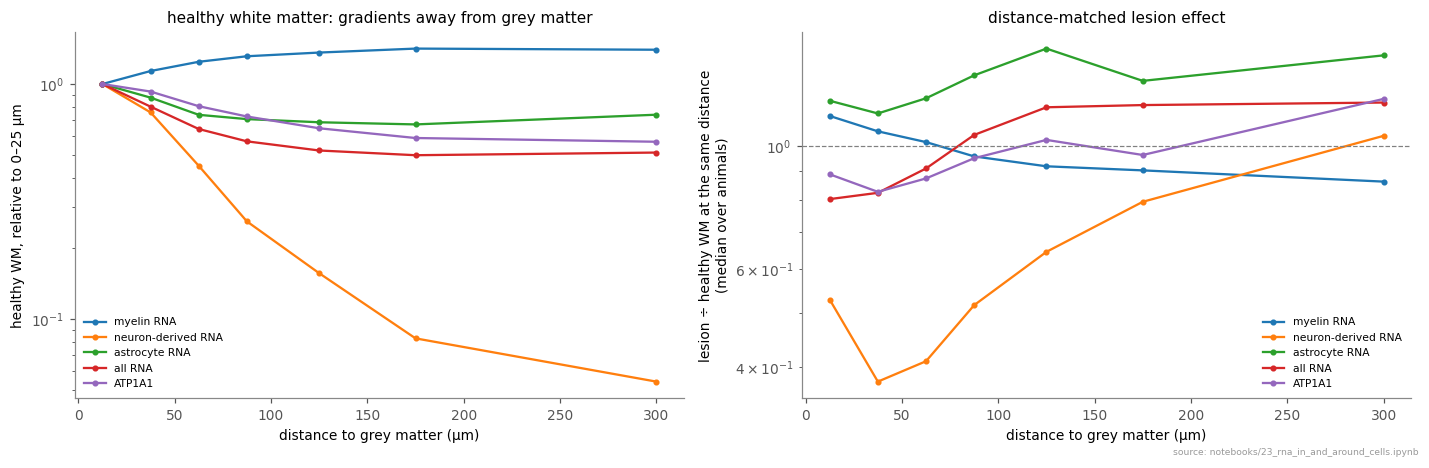

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
gn = grad / grad.iloc[0]
for i, k in enumerate(gn.columns):
    axs[0].plot([b.mid for b in gn.index], gn[k], marker="o", ms=3, color=plt.cm.tab10(i), label=k)
axs[0].set_yscale("log")
axs[0].set_xlabel("distance to grey matter (µm)")
axs[0].set_ylabel("healthy WM, relative to 0–25 µm")
axs[0].set_title("healthy white matter: gradients away from grey matter")
axs[0].legend(fontsize=7)
for i, k in enumerate(gn.columns):
    t = q4d[q4d.readout == k]
    axs[1].plot((t.lo + t.hi) / 2, t.ratio, marker="o", ms=3, color=plt.cm.tab10(i), label=k)
axs[1].axhline(1, color="0.5", ls="--", lw=0.8)
axs[1].set_yscale("log")
axs[1].set_xlabel("distance to grey matter (µm)")
axs[1].set_ylabel("lesion ÷ healthy WM at the same distance\n(median over animals)")
axs[1].set_title("distance-matched lesion effect")
axs[1].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "q4_distance_to_gm", OUT, SRC)

In [35]:
cor = pd.DataFrame([dict(x="ATP1A1", y=v, **dict(zip(["rho", "p"], spearmanr(np.log(q4p.ATP1A1), np.log(q4p[v]))))) for v in
                    list(MATS)]).round(3)
cor.to_csv(OUT / "q4_atp1a1_vs_rna_pieces.csv", index=False)
cor

,x,y,rho,p
0,ATP1A1,myelin RNA,0.243,0.131
1,ATP1A1,neuron-derived RNA,0.166,0.306
2,ATP1A1,astrocyte RNA,0.276,0.085
3,ATP1A1,all RNA,0.289,0.071


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/q4_neuropil_rna.png')

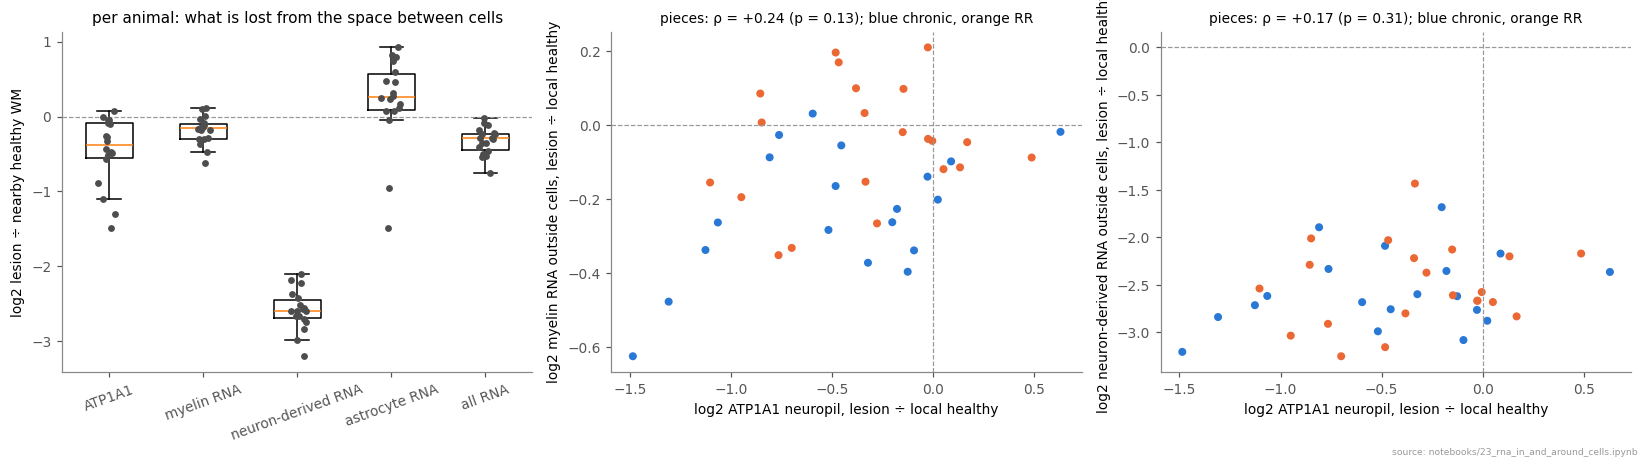

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
vv = ["ATP1A1", "myelin RNA", "neuron-derived RNA", "astrocyte RNA", "all RNA"]
lg = np.log2(an[vv])
axs[0].boxplot([lg[v].dropna() for v in vv], showfliers=False)
for i, v in enumerate(vv):
    axs[0].scatter(np.full(lg[v].notna().sum(), i + 1) + rng.normal(0, 0.05, lg[v].notna().sum()), lg[v].dropna(),
                   s=12, color="0.3", zorder=3)
axs[0].set_xticks(range(1, len(vv) + 1), vv, rotation=20)
axs[0].axhline(0, color="0.6", ls="--", lw=0.8)
axs[0].set_ylabel("log2 lesion ÷ nearby healthy WM")
axs[0].set_title("per animal: what is lost from the space between cells")
for ax, v in zip(axs[1:], ["myelin RNA", "neuron-derived RNA"]):
    ax.scatter(np.log2(q4p.ATP1A1), np.log2(q4p[v]), s=18, c=[COL[0] if a_ == "chronic" else COL[1] for a_ in q4p.arm])
    ax.axhline(0, color="0.6", ls="--", lw=0.8)
    ax.axvline(0, color="0.6", ls="--", lw=0.8)
    r = cor.set_index("y").loc[v]
    ax.set_xlabel("log2 ATP1A1 neuropil, lesion ÷ local healthy")
    ax.set_ylabel(f"log2 {v} outside cells, lesion ÷ local healthy")
    ax.set_title(f"pieces: ρ = {r.rho:+.2f} (p = {r.p:.2g}); blue chronic, orange RR", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "q4_neuropil_rna", OUT, SRC)

**Seeing it.** Random 40 µm white-matter fields centred on a random cell, one per random animal (seed 0): curated
lesion niche vs physiological WM. Myelin RNA outside outlines (cyan), neuron-derived RNA outside outlines (magenta), cell
outlines grey, nuclei blue. The claim to check by eye: less cyan between cells in lesions, with magenta (neuron-derived) RNA
behaving differently or not.

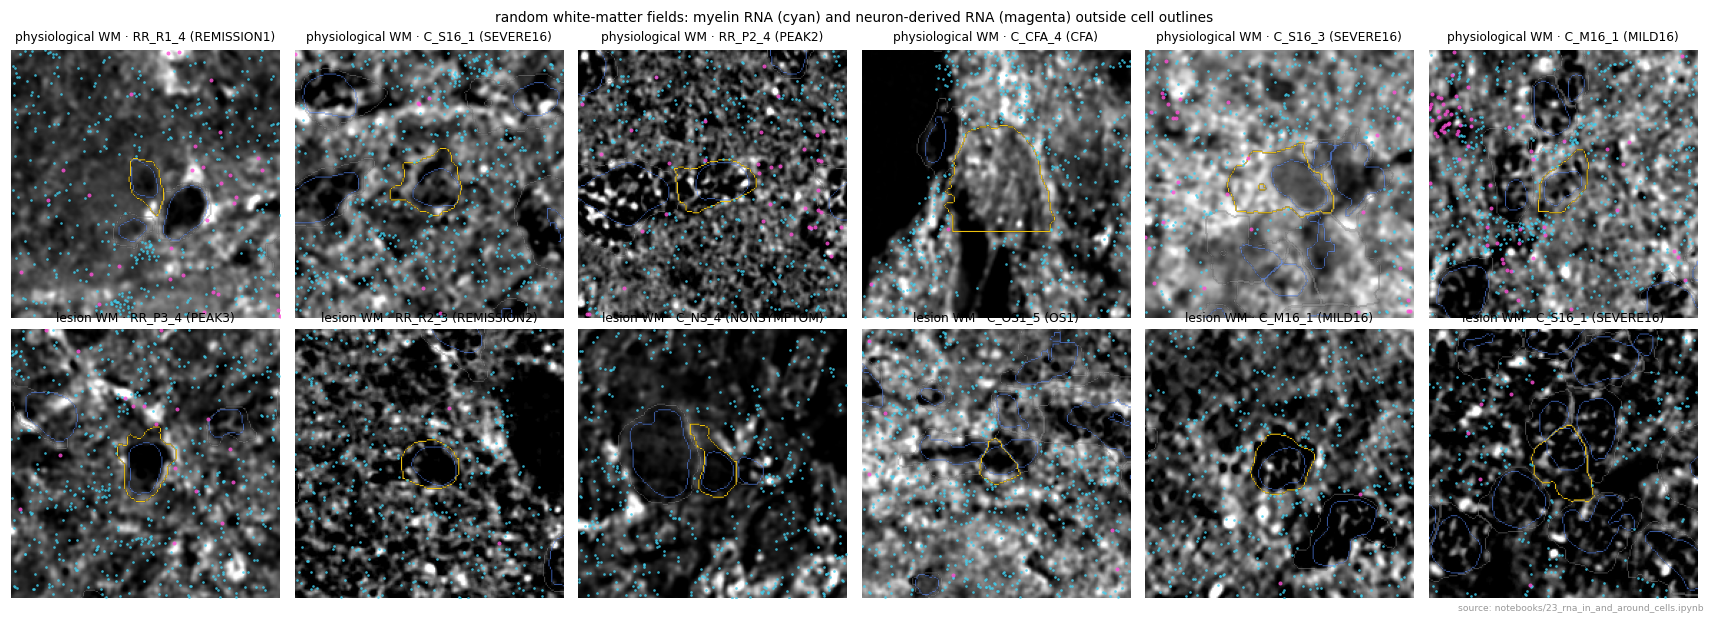

In [37]:
L4 = [([g for k in MYELIN for g in SETS[k]], False, "#3fd0f0", 3), (SETS["axon"], False, "#ff4fd8", 7)]
gallery([("physiological WM", w4[w4.zone_cur == "healthy"]), ("lesion WM", w4[w4.zone_cur == "core"])], 40, L4,
        suptitle="random white-matter fields: myelin RNA (cyan) and neuron-derived RNA (magenta) outside cell outlines",
        name="q4_gallery_random")

## 5. Across the disease course
Per animal (core ÷ healthy, log2) for the main readout of each question, by stage and against clinical score
(exploratory: few animals per stage).

In [38]:
summ = pd.DataFrame({
    "Mbp kept in soma (Q1)": np.log2(r_soma.unstack().core / r_soma.unstack().healthy),
    "own Mbp halo (Q1)": np.log2(r_halo.unstack().core / r_halo.unstack().healthy),
    "myeloid myelin uptake ÷ astro (Q2)": np.log2((up[("myeloid", "myelin")] / up[("astrocyte", "myelin")]).unstack().core),
    "oligo nuclear retention (Q3)": np.log2(nucz["Oligodendrocyte"].unstack().core / nucz["Oligodendrocyte"].unstack().healthy),
    "myeloid nuclear retention (Q3)": np.log2(nucz["Myeloid"].unstack().core / nucz["Myeloid"].unstack().healthy),
    "WM myelin RNA outside cells (Q4)": np.log2(an["myelin RNA"]),
    "WM neuron-derived RNA outside cells (Q4)": np.log2(an["neuron-derived RNA"]),
}).replace([np.inf, -np.inf], np.nan)
st = obs.drop_duplicates("sample_name").set_index("sample_name")[["stage", "arm"]]
summ = summ.join(st).join(clin[["score", "first_peak"]])
summ.round(3).to_csv(OUT / "per_animal_summary.csv")
rows = []
for c in summ.columns[:7]:
    for k in ["score", "first_peak"]:
        x = summ[[c, k]].dropna()
        if len(x) >= 8:
            r = spearmanr(x[c], x[k])
            rows.append(dict(readout=c, clinical=k, animals=len(x), rho=r.statistic, p=r.pvalue))
q5 = report(rows)
q5.to_csv(OUT / "course_vs_clinical.csv", index=False)
q5

,readout,clinical,animals,rho,p
0,Mbp kept in soma (Q1),score,15,-0.094,0.740
1,Mbp kept in soma (Q1),first_peak,15,-0.126,0.654
2,own Mbp halo (Q1),score,15,0.105,0.710
3,own Mbp halo (Q1),first_peak,15,-0.026,0.927
4,myeloid myelin uptake ÷ astro (Q2),score,20,-0.344,0.138
5,myeloid myelin uptake ÷ astro (Q2),first_peak,20,-0.126,0.597
6,oligo nuclear retention (Q3),score,15,0.371,0.173
7,oligo nuclear retention (Q3),first_peak,15,0.284,0.305
8,myeloid nuclear retention (Q3),score,15,0.303,0.272
9,myeloid nuclear retention (Q3),first_peak,15,0.208,0.457


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/23_rna_in_and_around_cells/course.png')

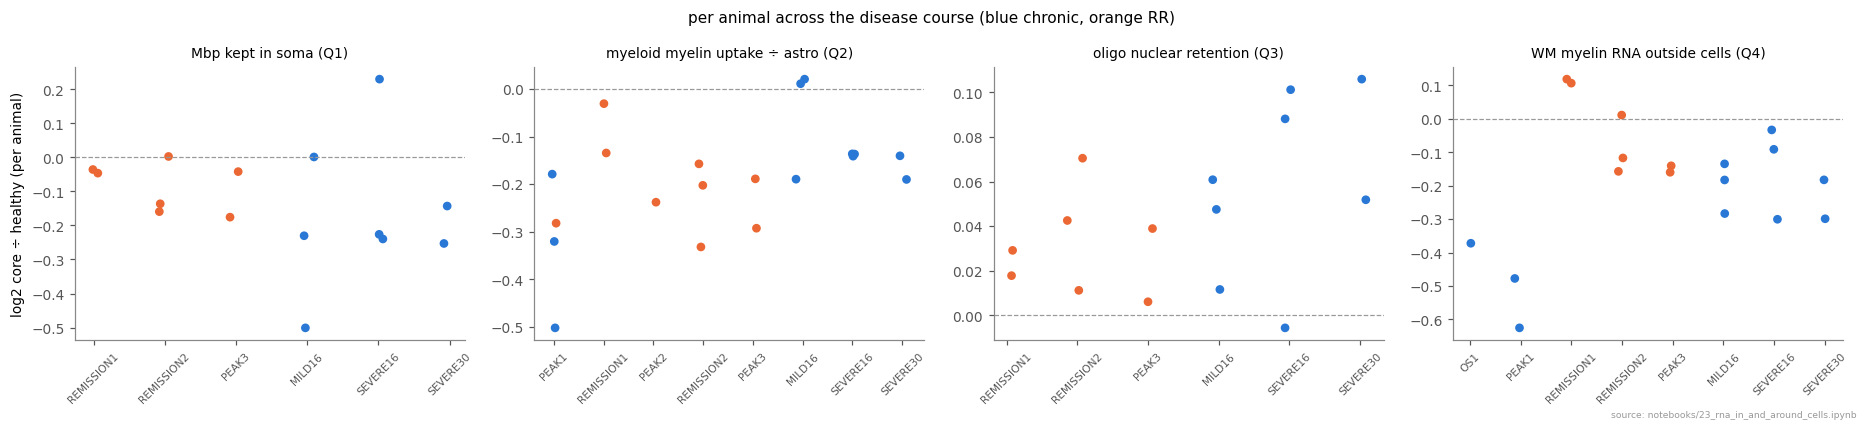

In [39]:
fig, axs = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, c in zip(axs, ["Mbp kept in soma (Q1)", "myeloid myelin uptake ÷ astro (Q2)", "oligo nuclear retention (Q3)",
                       "WM myelin RNA outside cells (Q4)"]):
    d = summ[[c, "stage", "arm"]].dropna()
    order = [s_ for s_ in STAGES if s_ in set(d.stage)]
    x = d.stage.map({s_: i for i, s_ in enumerate(order)})
    ax.scatter(x + rng.normal(0, 0.06, len(d)), d[c], c=[COL[0] if a_ == "chronic" else COL[1] for a_ in d.arm], s=22)
    ax.set_xticks(range(len(order)), order, rotation=45, fontsize=7)
    ax.axhline(0, color="0.6", ls="--", lw=0.8)
    ax.set_title(c, fontsize=9)
axs[0].set_ylabel("log2 core ÷ healthy (per animal)")
fig.suptitle("per animal across the disease course (blue chronic, orange RR)", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "course", OUT, SRC)

## Findings
(filled in after the run)